Patch foraging + FIP analyses, version 6. Updating functions to calculate baseline of PSTHs from specified pre-windows.

In [1]:
# IPython magig  tools
%load_ext autoreload
%autoreload 2

from os import PathLike
import os

from aind_vr_foraging_analysis.utils.parsing import parse, data_access
import aind_vr_foraging_analysis.utils.plotting as plotting

# Plotting libraries
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

import seaborn as sns
import pandas as pd
import numpy as np
import pytz
from datetime import datetime
sns.set_context('talk')

import warnings
pd.options.mode.chained_assignment = None  # Ignore SettingWithCopyWarning
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

color1='#d95f02'
color2='#1b9e77'
color3='#7570b3'
color4='yellow'
odor_list_color = [color1, color2, color3, color4]

color_dict_label = {'InterSite': '#808080',
    'InterPatch': '#b3b3b3', 'PatchZ': '#d95f02',
    'PatchZA': '#d95f02', 'PatchZB': '#d95f02', 
    'PatchB': '#d95f02','PatchA': '#7570b3', 
    'PatchC': '#1b9e77',
    'Alpha-pinene': '#1b9e77', 
    'Methyl Butyrate': '#7570b3', 
    'Amyl Acetate': '#d95f02', 
    'Fenchone': '#7570b3', 
    'Dipropyl sulfide': '#7570b3',
    'Dypropil sulfide': '#7570b3',
    'Hexanal': '#1b9e77',
    'Pentyl acetate': '#d95f02',
    'S': color1,
    'D': color2,
    'N': color3,   
    'Do': color1,
    'None': color4, 
    'odor_0': color3,
    'odor_60': color2,
    'odor_90': color1,
    'odor_fast': '#d95f02',
    'odor_slow': '#1b9e77',
    'A': color1,
    'B': color2,
    'C': color3,
    'OdorA': color1,
    'OdorB': color2,
    'OdorC': color3,
    }

label_dict = {
    **{"InterSite": '#808080', "InterPatch": '#b3b3b3'}, 
    **color_dict_label
}

pdf_path = r'C:\Users\jason.lee\OneDrive - Allen Institute\Documents\patch_foraging\sessions'
base_path = r'\\allen\aind\stage\vr-foraging\data'
foraging_figures = r'C:\Users\jason.lee\OneDrive - Allen Institute\Documents\patch_foraging'


In [83]:
#Session picker
from pathlib import Path

#session_path = Path(r"Y:\vr-foraging\data\822683\822683_2026-02-24T173212Z")
#session_path = Path(r"Y:\vr-foraging\data\822683\822683_2026-02-25T165952Z")
#session_path = Path(r"Y:\vr-foraging\data\822683\822683_2026-02-26T165938Z")
#session_path = Path(r"Y:\vr-foraging\data\822683\822683_2026-02-27T165358Z")
#session_path = Path(r"Y:\vr-foraging\data\822683\822683_2026-03-03T163705Z")
#session_path = Path(r"Y:\vr-foraging\data\822683\822683_2026-03-04T173230Z")
#session_path = Path(r"Y:\vr-foraging\data\822683\822683_2026-03-06T164451Z")

# session_path = Path(r"Y:\vr-foraging\data\816214\816214_2026-04-03T163550Z")
# session_path = Path(r"Y:\vr-foraging\data\816214\816214_2026-03-27T200349Z")
# session_path = Path(r"Y:\vr-foraging\data\816214\816214_2026-04-06T162038Z")
# session_path = Path(r"Y:\vr-foraging\data\816214\816214_2026-04-07T165705Z")
# session_path = Path(r"Y:\vr-foraging\data\816214\816214_2026-04-08T163555Z")
# session_path = Path(r"Y:\vr-foraging\data\816214\816214_2026-04-09T163952Z")
# session_path = Path(r"Y:\vr-foraging\data\816214\816214_2026-04-10T162442Z")
# session_path = Path(r"Y:\vr-foraging\data\816214\816214_2026-04-14T170046Z")
# session_path = Path(r"Y:\vr-foraging\data\816214\816214_2026-04-15T163601Z")
# session_path = Path(r"Y:\vr-foraging\data\816214\816214_2026-04-16T162449Z")
# session_path = Path(r"Y:\vr-foraging\data\816214\816214_2026-04-17T170302Z")
# session_path = Path(r"Y:\vr-foraging\data\816214\816214_2026-04-20T164418Z")
# session_path = Path(r"Y:\vr-foraging\data\816214\816214_2026-04-21T164819Z")

# session_path = Path(r"Y:\vr-foraging\data\808054\808054_2026-04-06T191116Z")
# session_path = Path(r"Y:\vr-foraging\data\808054\808054_2026-04-07T190234Z")
# session_path = Path(r"Y:\vr-foraging\data\808054\808054_2026-04-08T201406Z")
# session_path = Path(r"Y:\vr-foraging\data\808054\808054_2026-04-10T185226Z")
# session_path = Path(r"Y:\vr-foraging\data\808054\808054_2026-04-14T202415Z")
# session_path = Path(r"Y:\vr-foraging\data\808054\808054_2026-04-15T194220Z")
# session_path = Path(r"Y:\vr-foraging\data\808054\808054_2026-04-16T193824Z")
# session_path = Path(r"Y:\vr-foraging\data\808054\808054_2026-04-17T193309Z")

#session_path = Path(r"Y:\vr-foraging\data\788731\788731_2025-12-19T234013Z")
#session_path = Path(r"Y:\vr-foraging\data\788731\788731_2025-12-17T232028Z")
#session_path = Path(r"Y:\vr-foraging\data\788731\788731_2025-12-15T231441Z")
session_path = Path(r"Y:\vr-foraging\data\788731\788731_2025-12-12T231442Z")
#session_path = Path(r"Y:\vr-foraging\data\788731\788731_2025-12-11T194307Z")
#session_path = Path(r"Y:\vr-foraging\data\788731\788731_2025-12-10T235940Z")
#session_path = Path(r"Y:\vr-foraging\data\788731\788731_2025-12-09T191007Z")
#session_path = Path(r"Y:\vr-foraging\data\788731\788731_2025-12-08T225800Z")

#session_path = Path(r"Y:\vr-foraging\data\810351\810351_2025-12-20T002820Z")
#session_path = Path(r"Y:\vr-foraging\data\810351\810351_2025-12-18T000750Z")
#session_path = Path(r"Y:\vr-foraging\data\810351\810351_2025-12-16T000745Z")
#session_path = Path(r"Y:\vr-foraging\data\810351\810351_2025-12-13T000905Z")
#session_path = Path(r"Y:\vr-foraging\data\810351\810351_2025-12-11T184700Z")

# session_path = Path(r"Y:\vr-foraging\data\804430\804430_2025-11-20T235758Z")
# session_path = Path(r"Y:\vr-foraging\data\804430\804430_2025-11-24T233544Z")
# session_path = Path(r"Y:\vr-foraging\data\804430\804430_2025-11-25T232029Z")
# session_path = Path(r"Y:\vr-foraging\data\804430\804430_2025-11-26T234133Z")

# session_path = Path(r"Y:\vr-foraging\data\804434\804434_2025-11-22T000144Z")
# session_path = Path(r"Y:\vr-foraging\data\804434\804434_2025-11-25T004352Z")
# session_path = Path(r"Y:\vr-foraging\data\804434\804434_2025-11-26T001812Z")
# session_path = Path(r"Y:\vr-foraging\data\804434\804434_2025-11-27T003255Z")

subject_ID = int(session_path.parts[session_path.parts.index("data") + 1])
print(subject_ID)

session_date = session_path.name.split("_", 1)[1].split("T", 1)[0]
print(session_date)  # 2025-12-15


##if you know the exact name
# fip_dir = session_dir / "fib" / "fip_2025-12-03T164904"

# or, if you just know it's fip_***
fib_dir = session_path / "fib"
FIP_Dir = next(fib_dir.glob("fip_*"))  # gets the first folder matching fip_*
FIP_Dir = str(FIP_Dir)
print(FIP_Dir)

788731
2025-12-12
Y:\vr-foraging\data\788731\788731_2025-12-12T231442Z\fib\fip_2025-12-12T152023


In [3]:
def stage_to_numeric(stage_str):
    # Split the stage string
    parts = stage_str.split('_')

    # Find parts with "distance" and "stop"
    stage_part = next((p for p in parts if 'stage' in p), '')
    distance_part = next((p for p in parts if 'distance' in p), '')
    stop_part = next((p for p in parts if 'stop' in p), '')

    # Extract suffix letters
    distance_letter = distance_part.replace('distance', '') if 'distance' in distance_part else ''
    stop_letter = stop_part.replace('stop', '') if 'stop' in stop_part else ''
    stage_letter = stop_part.replace('stage', '') if 'stage' in stage_part else ''

    # Define letter-to-value mapping
    letter_value = {'B': 2, 'C': 3, 'D': 5, 'E':7}

    # Get values
    d_val = letter_value.get(distance_letter, 1)
    s_val = letter_value.get(stop_letter, 1)

    # If both are D, return 5
    if distance_letter == 'D' and stop_letter == 'D':
        return 6
    elif distance_letter == 'C' and stop_letter == 'C':
        return 4
    elif stage_letter == 'B':
        return 8
    else:
        return max(d_val, s_val)

In [4]:
# Function to assign codes
def get_condition_code(text):
    if 'delayed' in text:
        return 'D'
    elif 'single' in text:
        return 'S'
    elif 'no_reward' in text or 'noreward' in text:
        return 'N'
    elif 'double' in text:
        return 'Do'
    else:
        return text

In [5]:
class MetricsVrForaging():
    def __init__(self, session_path: PathLike):
        self.session_path = session_path
        self.active_site, self.stream_data, self.data = data_access.load_session(
        session_path
        )
        
        
        self.reward_sites = self.active_site.loc[self.active_site['label'] == 'OdorSite']

        utc = pytz.UTC
        local_tz = pytz.timezone("America/Los_Angeles")

        utc_str = self.data['config'].streams.session_input.data['date']
        utc_dt = datetime.fromisoformat(utc_str)        # full timestamp
        local_dt = utc_dt.replace(tzinfo=utc).astimezone(local_tz)
        self.session = str(local_dt.date())  
        self.mouse = int(self.data['config'].streams.session_input.data['subject'])
        self.stage = self.data['config'].streams.tasklogic_input.data['stage_name']
        self.rig_name = self.data['config'].streams.rig_input.data['rig_name']
        self.experimenter = self.data['config'].streams.session_input.data['experimenter'][0]
        self.updaters = self.data['config'].streams.tasklogic_input.data['task_parameters']['updaters']

        print(self.rig_name)
        print(self.stage)
        print(self.experimenter)
        
        if self.stage == 'thermistor screening':
            return
        
        self.df = self.retrieve_metrics()

    def retrieve_metrics(self) -> pd.DataFrame:
        reward_sites = self.reward_sites
        active_site = self.active_site
        data = self.data

        df = pd.DataFrame()
        # Summary of different relevants aspects -------------------------------------------------

        unrewarded_stops = reward_sites.loc[reward_sites.is_reward==0]['reward_amount'].count()
        rewarded_stops = reward_sites.loc[reward_sites.is_reward==1]['reward_amount'].count()
        water_collected = reward_sites.loc[(reward_sites['is_reward']==1)]['reward_amount'].sum()
        total_stops = reward_sites.loc[(reward_sites['is_choice']==True)]['reward_amount'].count()

        print('Total sites: ' ,len(reward_sites), ' | ', 'Total rewarded stops: ',rewarded_stops, '(',  np.round((rewarded_stops/total_stops)*100,2),'%) | ', 
            'Total unrewarded stops: ',unrewarded_stops,'(',  np.round((unrewarded_stops/total_stops)*100,2),'%) | ','Water consumed: ', water_collected, 'ul')

        print('Total travelled m: ', np.round(active_site.start_position.max()/100,2), ', current position (cm): ', data['operation_control'].streams.CurrentPosition.data.max()[0]
        )

        for odor_label in reward_sites.odor_label.unique():
            values = reward_sites.loc[(reward_sites['odor_label']==odor_label)&(reward_sites['is_reward']==1)]['reward_amount'].sum()
            print(f'{odor_label} {values} ul')
            
        df.at[0,'odor_sites_travelled'] = int(len(reward_sites))
        df.at[0,'distance_m'] = data['operation_control'].streams.CurrentPosition.data.max()[0]/100
        df.at[0,'water_collected_ul'] = water_collected
        df.at[0,'rewarded_stops'] = int(rewarded_stops)
        df.at[0,'total_stops'] = int(total_stops)
        df.at[0,'session_duration_min'] = (reward_sites.index[-1] - reward_sites.index[0])/60
        df.at[0, 'total_patches_visited'] = reward_sites.loc[reward_sites['site_number'] >= 1].patch_number.nunique()
        return df

    def retrieve_updater_values(self):
        # Initialize a pointer for the data values
        data_pointer = 0
        
        reward_sites = self.reward_sites
        data = self.data
        df = self.df
        
        # Helper function to safely extract stream data
        def get_stream_data(data, key):
            try:
                stream = data['updater_events'].streams[key].data['data']
                stream.reset_index(drop=True, inplace=True)
                return stream
            except (KeyError, AttributeError):
                return None

        # Load updater data safely
        stop_duration = get_stream_data(data, 'UpdaterStopDurationOffset')
        delay = get_stream_data(data, 'UpdaterRewardDelayOffset')
        velocity_threshold = get_stream_data(data, 'UpdaterStopVelocityThreshold')

        # Create new columns in reward_sites with default values
        reward_sites['delay_s'] = np.nan
        reward_sites['velocity_threshold_cms'] = np.nan
        reward_sites['stop_duration_s'] = np.nan

        data_pointer = 0
        try:
            for index, row in reward_sites.iterrows():
                if row['is_reward'] == 1:
                    if delay is not None and len(delay) > data_pointer:
                        reward_sites.at[index, 'delay_s'] = delay[data_pointer]
                    if velocity_threshold is not None and len(velocity_threshold) > data_pointer:
                        reward_sites.at[index, 'velocity_threshold_cms'] = velocity_threshold[data_pointer]
                    if stop_duration is not None and len(stop_duration) > data_pointer:
                        reward_sites.at[index, 'stop_duration_s'] = stop_duration[data_pointer]
                    data_pointer += 1
                else:
                    if delay is not None and len(delay) > data_pointer:
                        reward_sites.at[index, 'delay_s'] = delay[data_pointer]
                    if velocity_threshold is not None and len(velocity_threshold) > data_pointer:
                        reward_sites.at[index, 'velocity_threshold_cms'] = velocity_threshold[data_pointer]
                    if stop_duration is not None and len(stop_duration) > data_pointer:
                        reward_sites.at[index, 'stop_duration_s'] = stop_duration[data_pointer]
        except IndexError:
            if delay is not None:
                reward_sites.at[index, 'delay_s'] = delay.max()
            if velocity_threshold is not None:
                reward_sites.at[index, 'velocity_threshold_cms'] = velocity_threshold.max()
            if stop_duration is not None:
                reward_sites.at[index, 'stop_duration_s'] = stop_duration.max()

        # Summary of the training metrics
        reward_sites['odor_sites'] = np.arange(1, len(reward_sites) + 1)

        # Safely update df only if values exist
        if delay is not None:
            df.at[0, 'start_delay'] = reward_sites['delay_s'].min()
            df.at[0, 'end_delay'] = reward_sites['delay_s'].max()
            df.at[0, 'sites_to_max_delay'] = reward_sites[reward_sites['delay_s'] == reward_sites['delay_s'].max()].iloc[0]['odor_sites']

        if stop_duration is not None:
            df.at[0, 'start_stop_duration'] = reward_sites['stop_duration_s'].min()
            df.at[0, 'end_stop_duration'] = reward_sites['stop_duration_s'].max()
            df.at[0, 'sites_to_max_stop_duration'] = reward_sites[reward_sites['stop_duration_s'] == reward_sites['stop_duration_s'].max()].iloc[0]['odor_sites']
            df.at[0, 'rewarded_sites_in_max_stop'] = int(reward_sites[(reward_sites['stop_duration_s'] == reward_sites['stop_duration_s'].max()) & (reward_sites.is_choice == 1)]['odor_sites'].nunique())

        if velocity_threshold is not None:
            df.at[0, 'start_velocity_threshold'] = reward_sites['velocity_threshold_cms'].min()
            df.at[0, 'end_velocity_threshold'] = reward_sites['velocity_threshold_cms'].max()
            df.at[0, 'target_max_velocity_threshold'] = reward_sites['velocity_threshold_cms'].max()
            df.at[0, 'sites_to_min_velocity'] = reward_sites[reward_sites['velocity_threshold_cms'] == reward_sites['velocity_threshold_cms'].min()].iloc[0]['odor_sites']
            df.at[0, 'sites_to_max_velocity'] = reward_sites[reward_sites['velocity_threshold_cms'] == reward_sites['velocity_threshold_cms'].max()].iloc[0]['odor_sites']        
        
        self.reward_sites = reward_sites
        self.df = df

    def get_metrics(self):
        return self.df

    def get_reward_sites(self):
        return self.reward_sites
    
    def get_mouse_and_session(self):
        return self.mouse, self.session
    
    def run_pdf_summary(self):
        color1='#d95f02'
        color2='#1b9e77'
        color3='#7570b3'
        color4='#e7298a'

        color_dict_label = {'InterSite': '#808080',
            'InterPatch': '#b3b3b3', 'PatchZ': '#d95f02',
            'PatchZA': '#d95f02', 'PatchZB': '#d95f02', 
            'PatchB': '#d95f02','PatchA': '#7570b3', 
            'PatchC': '#1b9e77',
            'Alpha-pinene': '#1b9e77', 
            'Methyl Butyrate': '#7570b3', 
            'Amyl Acetate': '#d95f02', 
            'Fenchone': '#7570b3', 
            'Dipropyl sulfide': '#7570b3',
            'Dypropil sulfide': '#7570b3',
            'Hexanal': '#1b9e77',
            'Pentyl acetate': '#d95f02',
            'S': color1,
            'D': color2,
            'N': color3,   
            'Do': color1,
            'None': color4, 
            'odor_0': color3,
            'odor_60': color2,
            'odor_90': color1,
            'odor_fast': '#d95f02',
            'odor_slow': '#1b9e77',
            'A': color1,
            'B': color2,
            'C': color3,
            'OdorA': color1,
            'OdorB': color2,
            'OdorC': color3,
            }
        
        odor_sites = self.reward_sites.copy()
        encoder_data = self.stream_data.encoder_data
        active_site = self.active_site.copy()
        
        active_site['mouse'] = self.mouse
        active_site['session'] = self.session
        
        # Apply function
        active_site['long_patch_label'] = active_site['patch_label']
        active_site['patch_label'] = active_site['patch_label'].apply(get_condition_code)
        
        # odor_sites['odor_label'] = odor_sites['odor_label'].str.replace(' ', '_')
        
        # Remove segments where the mouse was disengaged
        last_engaged_patch = odor_sites['patch_number'][odor_sites['skipped_count'] >= 10].min()
        if pd.isna(last_engaged_patch):
            last_engaged_patch = odor_sites['patch_number'].max()
            
        odor_sites['engaged'] = odor_sites['patch_number'] <= last_engaged_patch  
    
        try:
            odor_sites['block'] = odor_sites['patch_label'].str.extract(r'set(\d+)').astype(int)
        except ValueError: 
            odor_sites['block'] = 0

        # Apply function
        odor_sites['long_patch_label'] = odor_sites['patch_label']
        odor_sites['patch_label'] = odor_sites['patch_label'].apply(get_condition_code)
        
        trial_summary = plotting.trial_collection(odor_sites[['is_choice', 'site_number', 'odor_label', 'depleted', 'odor_sites', 'is_reward','reward_probability','reward_amount','reward_available']], 
                                                  encoder_data, 
                                                  window=(-1,3)
                                                )
    
        # Save each figure to a separate page in the PDF
        pdf_filename = f'{self.mouse}_{self.session}_summary.pdf'
        with PdfPages(pdf_path+"\\"+pdf_filename) as pdf:
            text1 = ('Mouse: ' + str(self.mouse) 
            + '\nSession: ' + str(self.session) 
            + '\nRig: ' + str(self.rig_name) 
            + '\nStage: ' + str(self.stage)
            + '\nTotal sites travelled: '  + str(self.df.odor_sites_travelled.iloc[0]) 
            + '\nTotal choices: '  + str(self.df.total_stops.iloc[0]) 
            + '\nTotal rewarded stops: ' + str(self.df.rewarded_stops.iloc[0]) + ' (' +str(np.round((self.df.rewarded_stops.iloc[0]/self.df.total_stops.iloc[0])*100,2)) + '%) \n' 
            + 'Water consumed: ' +  str(np.round(self.df.water_collected_ul.iloc[0], 2)) + 'ul\n' 
            + 'Session duration: ' + str(np.round(self.df.session_duration_min.iloc[0],2)) + 'min\n' 
            + 'Total travelled m: ' + str(np.round(active_site.start_position.max()/100,2))
            )
            
            # '(',  np.round((rewarded_stops/total_stops)*100,2),'%) | ', 
            text_to_figure = text1
            # if self.stage[:7] == 'shaping':
            #     text2 = '\nTotal sites travelled: ' + str(self.df.odor_sites_travelled.iloc[0]) + '\nRewarded stops in max stop duration: ' + str(self.df.rewarded_sites_in_max_stop.iloc[0]) + '\nTotal patches visited: ' + str(self.df.total_patches_visited.iloc[0])
            #     text_to_figure = text1 + text2
            
            # Create a figure
            fig, ax = plt.subplots(figsize=(8.5, 11))  # Standard letter size
            ax.text(0.1, 0.9, text_to_figure, ha='left', va='center', fontsize=12)
            ax.axis('off')  # Hide the axes
            pdf.savefig(fig)
            plt.close(fig)
            
            # plotting.raster_with_velocity(active_site, stream_data, color_dict_label=color_dict_label, save=pdf)
            plotting.segmented_raster_vertical(odor_sites, 
                                            save=pdf, 
                                            color_dict_label=color_dict_label)
            plotting.raster_with_velocity(active_site, self.stream_data, color_dict_label=color_dict_label, save=pdf)
        
            plotting.summary_withinsession_values(odor_sites, 
                                    color_dict_label = color_dict_label, 
                                    save=pdf)
            plotting.speed_traces_efficient(trial_summary, self.mouse, self.session,  save=pdf)
            plotting.preward_estimates(odor_sites, 
                                    color_dict_label = color_dict_label, 
                                    save=pdf)
            plotting.speed_traces_value(trial_summary, self.mouse, self.session, condition = 'reward_probability', save=pdf) 
            plotting.velocity_traces_odor_entry(trial_summary, max_range = trial_summary.speed.max(), color_dict_label=color_dict_label, save=pdf)

            plotting.length_distributions(self.active_site, self.data, delay=True, save=pdf)
            if len(self.updaters):
                plotting.update_values(self.reward_sites, save=pdf)
            
        return pdf_filename


In [84]:
### Load Patch Foraging Data
all_epochs, stream_data, data = data_access.load_session(session_path)
all_epochs['patch_label'] = all_epochs['patch_label'].apply(get_condition_code)
# all epochs gives you a trial-based table segmented by interpatch, intersite or odorsite. Stream_data gives access to continuous data parsed for interpretability. 

pd.set_option('display.max_columns',None)
all_epochs

Reward functions from software events


,label,start_position,length,friction,patch_number,patch_label,odor_label,site_number,stop_time,choice_cue_time,reward_onset_time,succesful_wait_time,is_choice,is_reward,reward_amount,reward_probability,reward_available,odor_sites,collected,depleted,last_visit,last_site,cumulative_rewards,consecutive_rewards,cumulative_failures,consecutive_failures,after_choice_cumulative_rewards,duration_epoch,patch_onset,time_since_entry,exit_epoch,skipped_count
start_time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1.653948e+06,InterPatch,18.718401,268.064638,0.0,0,odor_60,Hexanal,NaN,1.653960e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.952000,1.653960e+06,-11.952000,0.000000,NaN
1.653960e+06,InterSite,286.783039,62.574261,0.0,0,odor_60,Hexanal,NaN,1.653963e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.976000,1.653960e+06,0.000000,2.976000,NaN
1.653963e+06,OdorSite,349.357300,50.000000,0.0,0,odor_60,Hexanal,0.0,1.653967e+06,1.653964e+06,1.653964e+06,1.653964e+06,True,True,5.0,0.600000,9999.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.581984,1.653960e+06,2.976000,7.557984,0.0
1.653967e+06,InterSite,399.357300,34.602706,0.0,0,odor_60,Hexanal,NaN,1.653970e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.268000,1.653960e+06,7.557984,9.825984,NaN
1.653970e+06,OdorSite,433.960006,50.000000,0.0,0,odor_60,Hexanal,1.0,1.653974e+06,1.653970e+06,1.653971e+06,1.653971e+06,True,True,5.0,0.527701,9999.0,1.0,5.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,2.0,4.424000,1.653960e+06,9.825984,14.249984,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1.656413e+06,InterPatch,48995.062500,296.168711,0.0,35,odor_90,Pentyl acetate,NaN,1.656437e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.456000,1.656437e+06,-23.456000,0.000000,NaN
1.656437e+06,InterSite,49291.231211,31.765929,0.0,35,odor_90,Pentyl acetate,NaN,1.656439e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.253984,1.656437e+06,0.000000,2.253984,NaN
1.656439e+06,OdorSite,49322.997141,50.000000,0.0,35,odor_90,Pentyl acetate,0.0,1.656441e+06,NaN,NaN,NaN,False,False,5.0,0.900000,9999.0,422.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.838016,1.656437e+06,2.253984,4.092000,8.0


In [85]:
parsed_session = MetricsVrForaging(session_path)
parsed_session.get_reward_sites().columns

Reward functions from software events
13A
graduation
jason.lee
Total sites:  423  |  Total rewarded stops:  160 ( 41.34 %) |  Total unrewarded stops:  263 ( 67.96 %) |  Water consumed:  800.0 ul
Total travelled m:  494.48 , current position (cm):  49467.1367
Hexanal 350.0 ul
Pentyl acetate 450.0 ul
Dipropyl sulfide 0.0 ul


Index(['label', 'start_position', 'length', 'friction', 'patch_number',
       'patch_label', 'odor_label', 'site_number', 'stop_time',
       'choice_cue_time', 'reward_onset_time', 'succesful_wait_time',
       'is_choice', 'is_reward', 'reward_amount', 'reward_probability',
       'reward_available', 'odor_sites', 'collected', 'depleted', 'last_visit',
       'last_site', 'cumulative_rewards', 'consecutive_rewards',
       'cumulative_failures', 'consecutive_failures',
       'after_choice_cumulative_rewards', 'duration_epoch', 'patch_onset',
       'time_since_entry', 'exit_epoch', 'skipped_count'],
      dtype='object')

In [86]:
### Load FIP data

# FIP_Dir = r'\\allen\aind\stage\vr-foraging\data\810351\810351_2025-12-04T004844Z\fib\fip_2025-12-03T164904'
# subjectID = "810351"

import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import csv
import glob
from scipy.optimize import curve_fit
import pandas as pd
from scipy.stats import sem

import PreprocessingFunctions_v2 as pf

# for visualization
Roi2Vis = [0, 1, 2, 3]

# params for pre-processing
nFrame2cut = 100  # crop initial n frames
sampling_rate = 20  # individual channel (not total)
kernelSize = 1  # median filter
degree = 4  # polyfit
b_percentile = 0.70  # To calculate F0, median of bottom x%

StimPeriod = 0.5  # sec for visualization
preW = 50  # nframes for PSTH
LickWindow = 5.0  # sec window length for Consummatory/Omission licks

try: 
    file1 = glob.glob(FIP_Dir + os.sep + "FIP_DataIso_*")[0]
    
except Exception as e:
    file1 = glob.glob(FIP_Dir + os.sep + "iso.csv")[0]
    file2 = glob.glob(FIP_Dir + os.sep + "green.csv")[0]
    file3 = glob.glob(FIP_Dir + os.sep + "red.csv")[0]   
    
else:
    file2 = glob.glob(FIP_Dir + os.sep + "green.csv")[0]
    file3 = glob.glob(FIP_Dir + os.sep + "red.csv")[0]

with open(file1) as f:
    reader = csv.reader(f)
    datatemp = np.array([row for row in reader])
    data1 = datatemp[1:,:].astype(np.float64)
    # del datatemp
    
with open(file2) as f:
    reader = csv.reader(f)
    datatemp = np.array([row for row in reader])
    data2 = datatemp[1:,:].astype(np.float64)
    # del datatemp
    
with open(file3) as f:
    reader = csv.reader(f)
    datatemp = np.array([row for row in reader])
    data3 = datatemp[1:,:].astype(np.float64)
    # del datatemp

#%%
# in case acquisition halted accidentally
Length = np.amin([len(data1),len(data2),len(data3)])

data1 = data1[0:Length] # iso       Time*[TS,ROI0,ROI1,ROI2,..]
data2 = data2[0:Length] # signal
data3 = data3[0:Length] # Stim

PMts = data2[:,0] #SignalTS
time_seconds = np.arange(len(data1)) /sampling_rate

#%% Preprocess
Ctrl_dF_F = np.zeros((data1.shape[0],data1.shape[1]))
G_dF_F = np.zeros((data1.shape[0],data1.shape[1]))
R_dF_F = np.zeros((data1.shape[0],data1.shape[1]))

for ii in range(data2.shape[1]-4):  # -4 to skip the first 4 columns (Fiber 0-3 are columns 4-7)
    Ctrl_dF_F[:, ii] = pf.tc_preprocess(data1[:,ii+4], nFrame2cut, kernelSize, sampling_rate, degree, b_percentile)
    G_dF_F[:, ii] = pf.tc_preprocess(data2[:,ii+4] , nFrame2cut, kernelSize, sampling_rate, degree, b_percentile)
    R_dF_F[:, ii] = pf.tc_preprocess(data3[:,ii+4] , nFrame2cut, kernelSize, sampling_rate, degree, b_percentile)
    


In [9]:
#%% PSTH functions (for multiple traces)
def PSTHmaker(TC, Stims, preW, postW):
    """Extract one time-by-channel window and preserve a 2-D shape.

    Samples requested outside the recording are padded with NaN. This keeps
    the output shape `(preW + postW, n_channels)` even at recording edges.
    """
    TC = np.asarray(TC, dtype=float)
    if TC.ndim == 1:
        TC = TC[:, None]
    if TC.ndim != 2:
        raise ValueError(f"TC must be 1-D or 2-D; got shape {TC.shape}")

    stim = int(Stims)
    preW = int(preW)
    postW = int(postW)
    if preW < 0 or postW < 0:
        raise ValueError(f"preW and postW must be non-negative; got {preW}, {postW}")

    requested_start = stim - preW
    requested_stop = stim + postW
    out = np.full((preW + postW, TC.shape[1]), np.nan, dtype=float)

    source_start = max(0, requested_start)
    source_stop = min(TC.shape[0], requested_stop)
    if source_start < source_stop:
        dest_start = source_start - requested_start
        dest_stop = dest_start + (source_stop - source_start)
        out[dest_start:dest_stop, :] = TC[source_start:source_stop, :]

    return out


def PSTHmaker_multi(TC, Stims, preW, postW):
    TC = np.asarray(TC)
    if TC.ndim == 1:
        TC = TC[:, None]  # (T, C=1)
    Stims = np.asarray(Stims, int)

    T, C = TC.shape
    W = preW + postW
    PSTHout = None

    for s in Stims:
        a, b = s - preW, s + postW
        if 0 <= a and b <= T:
            seg = TC[a:b, :]                             # (W, C)
        else:
            seg = np.full((W, C), np.nan, dtype=float)
            ai, bi = max(0, a), min(T, b)
            if ai < bi:
                seg[(ai - a):(bi - a), :] = TC[ai:bi, :]

        PSTHout = seg if PSTHout is None else np.dstack([PSTHout, seg])

    if PSTHout is None:
        raise ValueError("No events given.")

    # crucial: if only one event, force (W, C, 1)
    if PSTHout.ndim == 2:
        PSTHout = PSTHout[:, :, None]

    return PSTHout


#%%
def PSTHplot(PSTH, MainColor, SubColor, LabelStr):
    plt.plot(np.arange(np.shape(PSTH)[1])/20 - preW/sampling_rate, np.mean(PSTH.T,axis=1),label=LabelStr,color = MainColor, linewidth=0.5)
    #plt.plot(np.arange(np.shape(PSTH)[1])/20 - 5, np.mean(PSTH.T,axis=1) + np.std(PSTH.T,axis=1)/np.sqrt(np.shape(PSTH)[0]),color = SubColor, linestyle = "dotted")
    #plt.plot(np.arange(np.shape(PSTH)[1])/20 - 5, np.mean(PSTH.T,axis=1) - np.std(PSTH.T,axis=1)/np.sqrt(np.shape(PSTH)[0]),color = SubColor, linestyle = "dotted")
    # y11 =  np.mean(PSTH.T,axis=1) + np.std(PSTH.T,axis=1)/np.sqrt(np.shape(PSTH)[0])
    # y22 =  np.mean(PSTH.T,axis=1) - np.std(PSTH.T,axis=1)/np.sqrt(np.shape(PSTH)[0])
    # plt.fill_between(np.arange(np.shape(PSTH)[1])/20 - preW/sampling_rate, y11, y22, facecolor=SubColor, alpha=0.5)

def PSTHplot_multi(PSTH_w_by_trials, preW, color, subcolor, label):
    W = PSTH_w_by_trials.shape[0]
    t_rel = (np.arange(W) - preW) / sampling_rate
    y = np.nanmean(PSTH_w_by_trials, axis=1)  # mean across trials
    sem = np.nanstd(PSTH_w_by_trials, axis=1, ddof=1) / np.sqrt(np.sum(~np.isnan(PSTH_w_by_trials), axis=1))

    plt.plot(t_rel, y, color=color, lw=0.8, label=label)
    plt.fill_between(t_rel, y - sem, y + sem, alpha=0.3, facecolor=subcolor, linewidth=0)

#%% PSTH baseline subtraction (multi)
#dim0:trial, dim1:time
def PSTH_baseline(PSTH, preW):
    """Subtract the mean of the available pre-window samples per channel.

    The input/output shape is `(frames, channels)`. NaN padding from
    `PSTHmaker` is ignored. If no pre-window samples exist for a channel, that
    channel is left unshifted rather than turning the whole trace into NaN.
    """
    trace = np.asarray(PSTH, dtype=float)
    if trace.ndim == 1:
        trace = trace[:, None]
    if trace.ndim != 2:
        raise ValueError(f"PSTH must be 1-D or 2-D; got shape {trace.shape}")

    preW = int(preW)
    if preW <= 0 or preW > trace.shape[0]:
        raise ValueError(
            f"preW must be between 1 and the number of frames ({trace.shape[0]}); got {preW}"
        )

    baseline_region = trace[:preW, :]
    valid_counts = np.sum(np.isfinite(baseline_region), axis=0, keepdims=True)
    baseline_sums = np.nansum(baseline_region, axis=0, keepdims=True)
    baseline = np.divide(
        baseline_sums,
        valid_counts,
        out=np.zeros_like(baseline_sums, dtype=float),
        where=valid_counts > 0,
    )
    return trace - baseline


def generate_psth_multi(
    Ctrl_dF_F, G_df_F, R_df_F,
    roi_cols, stim_frames, preW, postW, fs,
    *,
    baseline_frames=None,          # array-like length K (one per trial) OR None
    baseline_win_s=(-2.0, 0.0),    # seconds relative to baseline_frames
):
    roi_cols = list(np.atleast_1d(roi_cols).astype(int))  # normalize

    stim_frames = np.asarray(stim_frames, dtype=int)

    # Extract aligned snippets: (W, C, K)
    C = PSTHmaker_multi(Ctrl_dF_F[:, roi_cols] * 100, stim_frames, preW, postW)
    G = PSTHmaker_multi(G_df_F[:,  roi_cols] * 100, stim_frames, preW, postW)
    R = PSTHmaker_multi(R_df_F[:,  roi_cols] * 100, stim_frames, preW, postW)

    if baseline_frames is None:
        # Original behavior: baseline from preW frames BEFORE the alignment event
        C = C - np.nanmean(C[:preW, :, :], axis=0, keepdims=True)
        G = G - np.nanmean(G[:preW, :, :], axis=0, keepdims=True)
        R = R - np.nanmean(R[:preW, :, :], axis=0, keepdims=True)
    else:
        baseline_frames = np.asarray(baseline_frames, dtype=int)
        if len(baseline_frames) != len(stim_frames):
            raise ValueError("baseline_frames must have the same length as stim_frames (one baseline per trial).")

        b0 = int(round(baseline_win_s[0] * fs))  # e.g. -40 for -2s @ 20 Hz
        b1 = int(round(baseline_win_s[1] * fs))  # e.g. 0

        def trialwise_baseline(trace_2d):
            # trace_2d: (T, C)
            T, Cn = trace_2d.shape
            K = len(baseline_frames)
            out = np.full((Cn, K), np.nan, dtype=float)  # (C, K) -> broadcasts to (W, C, K)

            for k, bf in enumerate(baseline_frames):
                i0, i1 = bf + b0, bf + b1
                if i1 <= i0 or i0 < 0 or i1 > T:
                    continue
                out[:, k] = np.nanmean(trace_2d[i0:i1, :], axis=0)

            return out

        baseC = trialwise_baseline(Ctrl_dF_F[:, roi_cols] * 100)  # (C, K)
        baseG = trialwise_baseline(G_df_F[:,  roi_cols] * 100)
        baseR = trialwise_baseline(R_df_F[:,  roi_cols] * 100)

        C = C - baseC[None, :, :]
        G = G - baseG[None, :, :]
        R = R - baseR[None, :, :]

    t_rel = (np.arange(preW + postW) - preW) / fs
    return C, G, R, t_rel


Behavioral Event-Aligned Photometry

In [10]:
# -----------------------
# DICTIONARIES
# -----------------------
ALIGNMENT_CFG = {
    "OdorSite": {
        "epoch_label": "OdorSite",
        "xlabel": "Time from odor site entry (s)",
        "title_prefix": "OdorSite",
    },
    "InterPatch": {
        "epoch_label": "InterPatch",
        "xlabel": "Time from patch leave (s)",   # tweak as needed
        "title_prefix": "PatchLeave",
    },
    "InterSite": {
        "epoch_label": "InterSite",
        "xlabel": "Time from site leave (s)",    # tweak as needed
        "title_prefix": "SiteLeave",
    },
    "RewardOnset": {
        "epoch_label": "OdorSite",  # we still use OdorSite rows, but align to reward_onset_time
        "xlabel": "Time from reward onset (s)",
        "title_prefix": "RewardOnset",
    }
}

REWARD_CFG = {
    True: {
        "title": "Reward",
        "file_tag": "rewarded",
    },
    False: {
        "title": "No Reward",
        "file_tag": "no_reward",
    },
}

SUBJECT_CFG = {
    788731: {
        "ROI0": {
            "roi_col": 0,
            "fiber_idx": 0,
            "hemisphere": "Left",
            "R_label": "NAc mShell GRAB-rAch1.7",
            "G_label": "NAc mShell dLight3.8",
            "Ctrl_label": "Iso",   # optional if you use it
        },
        "ROI1": {
            "roi_col": 1,
            "fiber_idx": 1,
            "hemisphere": "Right",
            "R_label": "NAc mShell GRAB-rDA",
            "G_label": "NAc mShell GRAB-5HT3",
            "Ctrl_label": "Iso",
        }
    }, 

    810351: {
        "ROI0": {
            "roi_col": 0,
            "fiber_idx": 0,
            "hemisphere": "Left",
            "R_label": "NAc mShell r5HT2.0",
            "G_label": "VTA→NAc mShell jGCaMP8s",
            "Ctrl_label": "Iso",   # optional if you use it
        },
        "ROI1": {
            "roi_col": 1,
            "fiber_idx": 1,
            "hemisphere": "Right",
            "R_label": "NAc mShell r5HT2.0",
            "G_label": "VTA→NAc mShell jGCaMP8s",
            "Ctrl_label": "Iso",
        }
    }, 

    804430: {
        "ROI0": {
            "roi_col": 0,
            "fiber_idx": 0,
            "hemisphere": "Left",
            "R_label": "ORBl rHT2.0",
            "G_label": "DRN->ORBl jGCaMP8s",
            "Ctrl_label": "Iso",   # optional if you use it
        },
        "ROI1": {
            "roi_col": 1,
            "fiber_idx": 1,
            "hemisphere": "Right",
            "R_label": "ORBm rHT2.0",
            "G_label": "DRN->ORBm jGCaMP8s",
            "Ctrl_label": "Iso",
        }
    }, 

    804434: {
        "ROI0": {
            "roi_col": 0,
            "fiber_idx": 0,
            "hemisphere": "Left",
            "R_label": "ORBl rHT2.0",
            "G_label": "DRN->ORBl jGCaMP8s",
            "Ctrl_label": "Iso",   # optional if you use it
        },
        "ROI1": {
            "roi_col": 1,
            "fiber_idx": 1,
            "hemisphere": "Right",
            "R_label": "ORBm rHT2.0",
            "G_label": "DRN->ORBm jGCaMP8s",
            "Ctrl_label": "Iso",
        }
    }, 

    808054: {
        "ROI0": {
            "roi_col": 0,
            "fiber_idx": 0,
            "hemisphere": "Left",
            "R_label": "None",
            "G_label": "LC->PL jGCaMP8s",
            "Ctrl_label": "Iso",
        },
        "ROI1": {
            "roi_col": 1,
            "fiber_idx": 1,
            "hemisphere": "Right",
            "R_label": "None",
            "G_label": "LC->PL jGCaMP8s",
            "Ctrl_label": "Iso",
        },
        "ROI2": {
            "roi_col": 2,
            "fiber_idx": 2,
            "hemisphere": "Left",
            "R_label": "latNAc rAch",
            "G_label": "latNAc dLight3.8",
            "Ctrl_label": "Iso",
        },
        "ROI3": {
            "roi_col": 3,
            "fiber_idx": 3,
            "hemisphere": "Right",
            "R_label": "latNAc rAch",
            "G_label": "latNAc dLight3.8",
            "Ctrl_label": "Iso",
        },
    },

    816214: {
        "ROI0": {
            "roi_col": 0,
            "fiber_idx": 0,
            "hemisphere": "Left",
            "R_label": "None",
            "G_label": "LC->PL jGCaMP8s",
            "Ctrl_label": "Iso",
        },
        "ROI1": {
            "roi_col": 1,
            "fiber_idx": 1,
            "hemisphere": "Right",
            "R_label": "None",
            "G_label": "LC->PL jGCaMP8s",
            "Ctrl_label": "Iso",
        },
        "ROI2": {
            "roi_col": 2,
            "fiber_idx": 2,
            "hemisphere": "Left",
            "R_label": "latNAc rAch",
            "G_label": "latNAc dLight3.8",
            "Ctrl_label": "Iso",
        },
        "ROI3": {
            "roi_col": 3,
            "fiber_idx": 3,
            "hemisphere": "Right",
            "R_label": "latNAc rAch",
            "G_label": "latNAc dLight3.8",
            "Ctrl_label": "Iso",
        },
    },

    822683: {
        "ROI0": {
            "roi_col": 0,
            "fiber_idx": 0,
            "hemisphere": "Left",
            "R_label": "PL GRAB-rNE1m",
            "G_label": "LC->PL jGCaMP8s",
            "Ctrl_label": "Iso",
        },
        "ROI1": {
            "roi_col": 1,
            "fiber_idx": 1,
            "hemisphere": "Right",
            "R_label": "PL GRAB-rNE1m",
            "G_label": "LC->PL jGCaMP8s",
            "Ctrl_label": "Iso",
        }
    }    
}


In [53]:
#WIDGET PLOT
# %matplotlib inline
from matplotlib.patches import Rectangle

def add_position(df: pd.DataFrame, position: pd.DataFrame):
    position.rename_axis('Time', axis='index', inplace=True)
    df.rename_axis('Time', axis='index', inplace=True)

    df = pd.merge_asof(df.sort_index(), position.sort_index(), direction='nearest', on="Time").set_index("Time").sort_index()
    df.columns = [*df.columns[:-1], 'Position']
    return df

def plot_patches(ax, navigation_mode, zero_index, _legend):
    """Plot the context patches based on the navigation mode."""
    _sites = add_position(all_epochs, position=stream_data.position_data)
    for idx, site in enumerate(all_epochs.iloc[:-1].iterrows()):
        site_label = site[1]["label"]
        if site_label == "Reward":
            site_label = f"Odor {site[1]['odor']['index'] + 1}"
            facecolor = label_dict[site_label]
        elif site_label == "OdorSite":
            site_label = site[1]['patch_label']
            facecolor = label_dict[site_label]
        elif site_label == "InterPatch":
            facecolor = label_dict[site_label]
        else:
            site_label = "InterSite"
            facecolor = label_dict["InterSite"]

        if navigation_mode == "space":
            position = _sites["Position"].values[idx]
            width = _sites["Position"].values[idx + 1] - position
            p = Rectangle((position, -2), width, 8, linewidth=0, facecolor=facecolor, alpha=0.5)
        else:
            time_position = all_epochs.index[idx] - zero_index
            width = all_epochs.index[idx + 1] - all_epochs.index[idx]
            p = Rectangle((time_position, -2), width, 8, linewidth=0, facecolor=facecolor, alpha=0.5)

        _legend[site_label] = p
        ax.add_patch(p)

def plot_behavioral_events(ax, navigation_mode, zero_index, _legend):
    """Plot the behavioral events based on the selected navigation mode."""
    events = [
        ("SoftReward", data['software_events'].streams['GiveReward'].data, 3.5, 'red', 'x', 400),
        ("SoftTone", data['software_events'].streams['ChoiceFeedback'].data, 2.5, 'yellow', 'x', 400),
        ('ChoiceFeedback', stream_data.choice_feedback, 2.5, 'k', 's', 100),
        ('Lick', stream_data.lick_onset, 1, 'k', '|', 100),
        ('Reward', stream_data.give_reward, 3.5, 'mediumblue', '*', 100),
    ]

    for event_name, event_data, y_pos, color, marker, size in events:
        if navigation_mode in ("time", "patch"):
            _legend[event_name] = ax.scatter(
                event_data.index - zero_index,
                [y_pos] * len(event_data.index),
                label=event_name,
                color=color,
                marker=marker,
                s=size,
            )
        else:
            positions = add_position(event_data, stream_data.position_data)['Position'].values
            _legend[event_name] = ax.scatter(
                positions,
                [y_pos] * len(positions),
                label=event_name,
                color=color,
                marker=marker,
                s=size,
            )

nav_config = {
    "patch": {"increment": 1},
    "time": {"increment": 30},
    "space": {"increment": 750},
}

def get_fiber_cfg(subject_id: int, roi_key: str):
    if subject_id not in SUBJECT_CFG:
        raise KeyError(f"Subject {subject_id} not in SUBJECT_CFG")
    if roi_key not in SUBJECT_CFG[subject_id]:
        raise KeyError(
            f"ROI key {roi_key} not in SUBJECT_CFG[{subject_id}]. "
            f"Keys: {list(SUBJECT_CFG[subject_id].keys())}"
        )
    return SUBJECT_CFG[subject_id][roi_key]

def get_visible_roi_keys(subject_id: int, roi_indices=None):
    if roi_indices is None:
        roi_indices = Roi2Vis
    out = []
    for roi_idx in roi_indices:
        roi_key = f"ROI{int(roi_idx)}"
        if roi_key in SUBJECT_CFG[subject_id]:
            out.append(roi_key)
    if not out:
        raise ValueError(f"No valid ROI keys found for subject {subject_id} and Roi2Vis={roi_indices}")
    return out

def update_plot(x_start, navigation_mode="time"):
    """
    Update the plot based on the selected navigation mode (space, time, or patch).
    """
    zero_index = all_epochs.index[0]
    roi_keys = get_visible_roi_keys(subject_ID)

    fig = plt.figure(figsize=(20, 3 + 2.2 * len(roi_keys)))
    gs = fig.add_gridspec(
        1 + len(roi_keys), 1,
        height_ratios=[2] + [1] * len(roi_keys),
        hspace=0.2,
    )

    ax = fig.add_subplot(gs[0])
    photometry_axes = [fig.add_subplot(gs[i + 1], sharex=ax) for i in range(len(roi_keys))]

    nav_mode = nav_config.get(navigation_mode, nav_config["time"])

    if navigation_mode == "patch":
        patch_start_times = all_epochs.loc[all_epochs['label'] == 'InterPatch'].index
        patch_end_times = patch_start_times[1:].append(pd.Index([all_epochs.index[-1]]))
        patches = list(zip(patch_start_times, patch_end_times))

        current_patch = int(x_start)
        current_patch = int(np.clip(current_patch, 0, max(len(patches) - 1, 0)))
        start, end = patches[current_patch]
        ax.set_xlim(start - zero_index, end - zero_index)
    else:
        x0 = x_start
        x1 = x_start + nav_mode.get("increment")
        ax.set_xlim(x0, x1)

        if navigation_mode == "time":
            start = zero_index + x0
            end = zero_index + x1
        else:  # "space"
            pos = stream_data.position_data["Position"] if "Position" in stream_data.position_data.columns else stream_data.position_data.squeeze()
            pos = np.asarray(pos, float)
            pos_time = np.asarray(stream_data.position_data.index, float)
            start = np.interp(x0, pos, pos_time, left=pos_time[0], right=pos_time[-1])
            end = np.interp(x1, pos, pos_time, left=pos_time[0], right=pos_time[-1])

    _legend = {}
    plot_patches(ax, navigation_mode, zero_index, _legend)
    plot_behavioral_events(ax, navigation_mode, zero_index, _legend)

    ax2 = ax.twinx()
    if navigation_mode in ("time", "patch"):
        _legend["Velocity"] = ax2.plot(
            stream_data.encoder_data.index - zero_index,
            stream_data.encoder_data.filtered_velocity,
            c="k", label="Velocity", alpha=0.8
        )[0]
    else:
        _legend["Velocity"] = ax2.plot(
            add_position(stream_data.encoder_data.filtered_velocity, position=stream_data.position_data)["Position"].values,
            stream_data.encoder_data.filtered_velocity.values,
            c="k", label="Encoder", alpha=0.8
        )[0]

    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.set_xlabel("Time (s)" if navigation_mode != "space" else "VR Space (cm)")
    ax2.set_ylabel("Velocity (cm/s)")
    ax.set_ylim(bottom=-1, top=4)
    ax.set_yticks([0, 3])
    ax2.yaxis.tick_left()
    ax2.yaxis.set_label_position("left")
    ax.grid(False)
    ax2.set_ylim((-10, 70))
    ax.legend(_legend.values(), _legend.keys(), bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0.)

    # Plot photometry for selected window.
    # Keep this local: later notebook cells change the global variable `preW`.
    widget_preW = 50
    fip_t = np.asarray(data1[:, 0], dtype=float)

    if end <= fip_t[0] or start >= fip_t[-1]:
        message = (
            f"No photometry overlap for selected interval {start:.3f}-{end:.3f} s; "
            f"FIP range is {fip_t[0]:.3f}-{fip_t[-1]:.3f} s."
        )
        for axp, roi_key in zip(photometry_axes, roi_keys):
            panel_cfg = get_fiber_cfg(subject_ID, roi_key)
            hemi = panel_cfg.get("hemisphere", "Unknown")
            axp.text(0.5, 0.5, message, ha="center", va="center", transform=axp.transAxes)
            axp.set_ylabel(f'dF/F (%)\n{roi_key} ({hemi})')
        photometry_axes[-1].set_xlabel(
            "Time (s)" if navigation_mode != "space" else "VR Space (cm)"
        )
        print(message)
        return fig

    # searchsorted gives insertion boundaries and permits endFrame == len(fip_t).
    startFrame = int(np.searchsorted(fip_t, start, side="left"))
    endFrame = int(np.searchsorted(fip_t, end, side="left"))
    startFrame = int(np.clip(startFrame, 0, len(fip_t) - 1))
    endFrame = int(np.clip(endFrame, 0, len(fip_t)))

    if endFrame <= startFrame:
        message = (
            f"Selected interval maps to no FIP samples: frames {startFrame}:{endFrame}; "
            f"times {start:.3f}-{end:.3f} s."
        )
        for axp in photometry_axes:
            axp.text(0.5, 0.5, message, ha="center", va="center", transform=axp.transAxes)
        print(message)
        return fig

    postW = endFrame - startFrame
    Psth_G = PSTHmaker(G_dF_F * 100, startFrame, widget_preW, postW)
    Psth_R = PSTHmaker(R_dF_F * 100, startFrame, widget_preW, postW)
    Psth_C = PSTHmaker(Ctrl_dF_F * 100, startFrame, widget_preW, postW)

    Psth_G_base = PSTH_baseline(Psth_G, widget_preW)
    Psth_R_base = PSTH_baseline(Psth_R, widget_preW)
    Psth_C_base = PSTH_baseline(Psth_C, widget_preW)

    # Anchor frame zero to the actual FIP timestamp selected for `start`.
    psth_time = (np.arange(Psth_G_base.shape[0]) - widget_preW) / sampling_rate
    psth_time_session = psth_time + (fip_t[startFrame] - zero_index)

    if startFrame < widget_preW:
        print(
            f"Only {startFrame} of {widget_preW} requested pre-window frames are available; "
            "baseline uses the available samples (or leaves the trace unshifted if none exist)."
        )

    def plot_one_panel(axp, panel_cfg, roi_key):
        i = panel_cfg["fiber_idx"]
        hemi = panel_cfg.get("hemisphere", "Unknown")

        axp.plot(
            psth_time_session, Psth_G_base[:, i],
            label=panel_cfg["G_label"], color="g", linewidth=0.5
        )
        axp.plot(
            psth_time_session, Psth_R_base[:, i],
            label=panel_cfg["R_label"], color="r", linewidth=0.5
        )
        axp.plot(
            psth_time_session, Psth_C_base[:, i],
            label="Isosbestic signal", color="b", linewidth=0.5
        )

        phot_handles, phot_labels = axp.get_legend_handles_labels()
        axp.legend(
            phot_handles, phot_labels,
            loc="upper left",
            bbox_to_anchor=(1.02, 0.8),
            borderaxespad=0.,
            frameon=False,
        )
        axp.set_ylabel(f'dF/F (%)\n{roi_key} ({hemi})')

    for axp, roi_key in zip(photometry_axes, roi_keys):
        panel_cfg = get_fiber_cfg(subject_ID, roi_key)
        plot_one_panel(axp, panel_cfg, roi_key)

    photometry_axes[-1].set_xlabel("Time (s)" if navigation_mode != "space" else "VR Space (cm)")

    print(startFrame, endFrame, start, end, np.shape(Psth_G_base), np.shape(psth_time))
    return fig

def on_left_button_clicked(button):
    if navigation_mode_widget.value == "patch":
        x_start_widget.value -= 1
    else:
        x_start_widget.value -= nav_config[navigation_mode_widget.value]["increment"]

def on_right_button_clicked(button):
    if navigation_mode_widget.value == "patch":
        x_start_widget.value += 1
    else:
        x_start_widget.value += nav_config[navigation_mode_widget.value]["increment"]

def save_plot(button):
    fig = update_plot(x_start_widget.value, navigation_mode_widget.value)
    save_name = "current_plot.png"
    fig.savefig(save_name, bbox_inches='tight', pad_inches=0.1, transparent=True)
    print(f"Plot saved as {save_name}")

import ipywidgets as widgets
from IPython.display import display

left_button = widgets.Button(description='◄')
right_button = widgets.Button(description='►')
save_button = widgets.Button(description='Save Plot')
save_button.on_click(save_plot)

x_start_widget = widgets.FloatText(value=0.0, description='X start:', continuous_update=True)

navigation_mode_widget = widgets.Dropdown(
    options=['time', 'space', 'patch'],
    value='patch',
    description='Nav Mode:',
    disabled=False
)

left_button.on_click(on_left_button_clicked)
right_button.on_click(on_right_button_clicked)

button_box = widgets.HBox([left_button, right_button, navigation_mode_widget, save_button])
ui = widgets.VBox([button_box, x_start_widget])

interactive_plot = widgets.interactive_output(
    update_plot,
    {'x_start': x_start_widget, 'navigation_mode': navigation_mode_widget}
)

display(ui, interactive_plot)

Output()

In [ ]:
def plot_mean_sem(t_rel, P, color, fill, label):
    # P is (W, trials) after selecting channel
    m  = np.nanmean(P, axis=1)
    se = np.nanstd(P, axis=1, ddof=1) / np.sqrt(np.sum(~np.isnan(P), axis=1))
    plt.plot(t_rel, m, color=color, lw=0.9, label=label)
    plt.fill_between(t_rel, m-se, m+se, alpha=0.25, facecolor=fill, linewidth=0)


def get_start_frames(all_epochs: pd.DataFrame, t: np.ndarray, alignment: str, is_reward: bool):
    """
    Returns startFrames (int indices into t) for the requested alignment.
    alignment:
      - "OdorSite" / "InterPatch" / "InterSite": uses row index timestamps
      - "RewardOnset": uses all_epochs["reward_onset_time"] (must be in same seconds as t)
    """
    ae = all_epochs.sort_index()
    align_cfg = ALIGNMENT_CFG[alignment]
    epoch_label = align_cfg["epoch_label"]

    mask = (
        (ae["label"] == epoch_label)
        & (ae["is_choice"].astype(bool))
        & (ae["is_reward"].astype(bool) == bool(is_reward))
    )

    if alignment == "RewardOnset":
        if "reward_onset_time" not in ae.columns:
            raise KeyError("Alignment='RewardOnset' requires all_epochs['reward_onset_time'] column.")

        starts = ae.loc[mask, "reward_onset_time"].astype(float)
        # drop NaNs (unrewarded OdorSites have NaN reward_onset_time)
        starts = starts[np.isfinite(starts.values)].to_numpy(dtype=float)

    else:
        # default: alignment to the row timestamp (index)
        starts = ae.index[mask].to_numpy(dtype=float)

    # convert start times (seconds) -> frame indices into t
    starts = np.asarray(starts, float)
    startFrames = np.searchsorted(t, starts).astype(int)

    return startFrames


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_photometry_psth(
    all_epochs, data1, Ctrl_dF_F, G_dF_F, R_dF_F,
    *,
    alignment="OdorSite",      # 'OdorSite', 'RewardOnset', 'InterPatch', 'InterSite'
    is_reward=True,            # True / False
    subject=subject_ID,        # 788731 / 810351 / ...
    hemisphere="Right",        # backward-compatible alias for ROI1 / ROI0
    roi_key=None,              # preferred: "ROI0"..."ROI3"
    preW=80,
    postW=200,
    fs=20,
    save_fig=False,
    outfile_base=None,
    xlims=(-2, 6),
    ylims=(-5, 5),
):

    # ---- look up config ----
    align_cfg = ALIGNMENT_CFG[alignment]
    reward_cfg = REWARD_CFG[is_reward]
    roi_key = roi_key or hemisphere
    subj_cfg = SUBJECT_CFG[subject][roi_key]

    roi_col = subj_cfg["roi_col"]
    fiber_idx = subj_cfg["fiber_idx"]
    hemi = subj_cfg.get("hemisphere", hemisphere)

    # ---- timestamps & start frames ----
    t = data1[:, 0].astype(float)
    ae = all_epochs.sort_index()

    if alignment == "RewardOnset":
        mask = (
            (ae["label"] == "OdorSite")
            & (ae["is_choice"].astype(bool))
            & (ae["is_reward"].astype(bool) == bool(is_reward))
            & (ae["reward_onset_time"].notna())
            & (ae["patch_onset"].notna())
        )

        reward_times = ae.loc[mask, "reward_onset_time"].astype(float).to_numpy(float)
        patch_onsets = ae.loc[mask, "patch_onset"].astype(float).to_numpy(float)

        startFrames = np.searchsorted(t, reward_times).astype(int)
        baseFrames = np.searchsorted(t, patch_onsets).astype(int)
    else:
        startFrames = get_start_frames(all_epochs, t, alignment, is_reward)
        baseFrames = None

    # ---- PSTHs ----
    psth_C, psth_G, psth_R, t_rel = generate_psth_multi(
        Ctrl_dF_F, G_dF_F, R_dF_F,
        roi_cols=[roi_col],
        stim_frames=startFrames,
        preW=preW,
        postW=postW,
        fs=fs,
        baseline_frames=baseFrames,
        baseline_win_s=(-2.0, 0.0),
    )

    # ---- plotting ----
    fig = plt.figure(figsize=(7, 4))
    ax = fig.add_subplot(111)

    plot_mean_sem(t_rel, psth_R[:, 0, :], "r", "lightcoral", subj_cfg["R_label"])
    plot_mean_sem(t_rel, psth_G[:, 0, :], "g", "lightgreen", subj_cfg["G_label"])
    plot_mean_sem(t_rel, psth_C[:, 0, :], "b", "lightblue", "Isosbestic")

    ax.axvline(0, color="k", ls="--", lw=0.8)
    ax.set_xlabel(align_cfg["xlabel"])
    ax.set_ylabel(f"dF/F (%) Fiber {fiber_idx}")

    if xlims is not None:
        ax.set_xlim(*xlims)
    if ylims is not None:
        ax.set_ylim(*ylims)

    ax.legend(frameon=False, loc="upper right", fontsize=9)

    title = (
        f"{align_cfg['title_prefix']} - Choice - {reward_cfg['title']} "
        f"- fiber{fiber_idx} - {hemi.lower()} hemi ({roi_key})"
    )
    fig.suptitle(title, y=1.02, fontsize=12)
    fig.tight_layout()

    svg_path = jpg_path = None

    if save_fig:
        if outfile_base is None:
            outfile_base = (
                f"m{subject}_{alignment}_{reward_cfg['file_tag']}_"
                f"fiber{fiber_idx}_{hemi.lower()}_{roi_key.lower()}"
            )

        svg_path = outfile_base + ".svg"
        jpg_path = outfile_base + ".jpg"

        fig.savefig(svg_path, format="svg", bbox_inches="tight")
        fig.savefig(jpg_path, format="jpg", bbox_inches="tight", dpi=300)

    return {
        "fig": fig,
        "ax": ax,
        "psth_C": psth_C,
        "psth_G": psth_G,
        "psth_R": psth_R,
        "t_rel": t_rel,
        "startFrames": startFrames,
        "svg_path": svg_path,
        "jpg_path": jpg_path,
        "roi_key": roi_key,
        "hemisphere": hemi,
    }

ordinal 1: n_events = 55
ordinal 2: n_events = 43
ordinal 3: n_events = 27
ordinal 4: n_events = 18
ordinal 5: n_events = 12
ordinal 6: n_events = 9
ordinal 7: n_events = 7
ordinal 8: n_events = 4


C:\Users\jason.lee\AppData\Local\Temp\ipykernel_27644\3166740656.py:95: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("coolwarm")


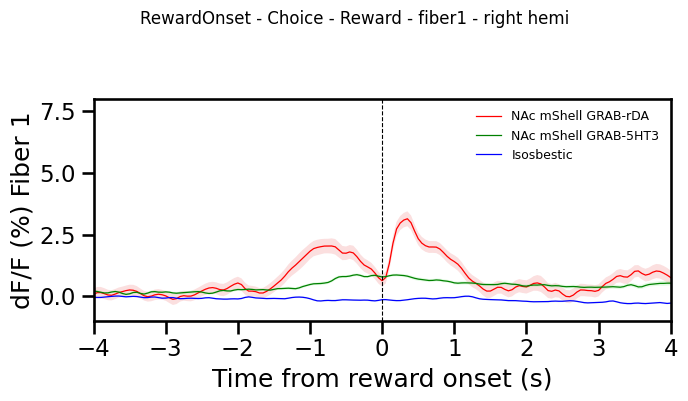

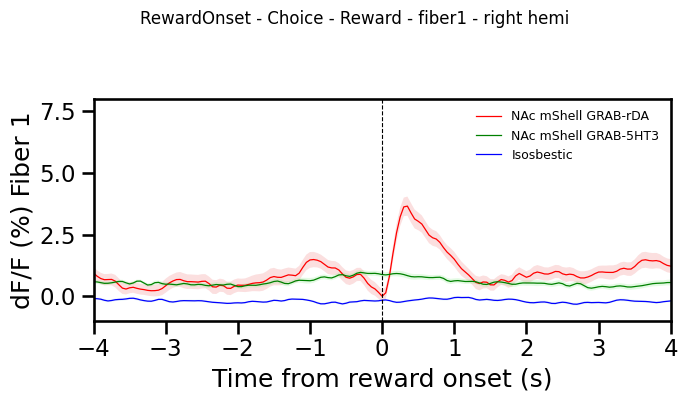

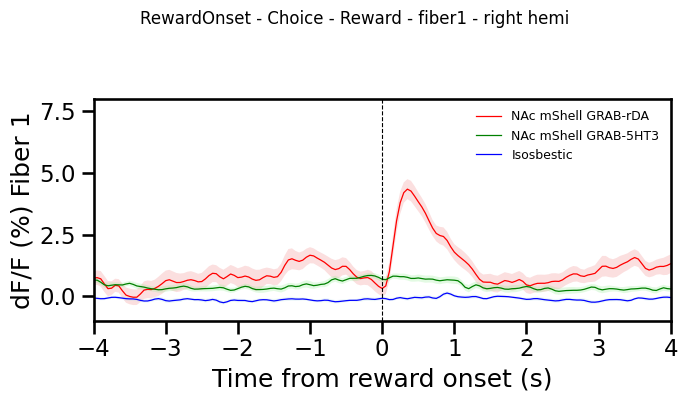

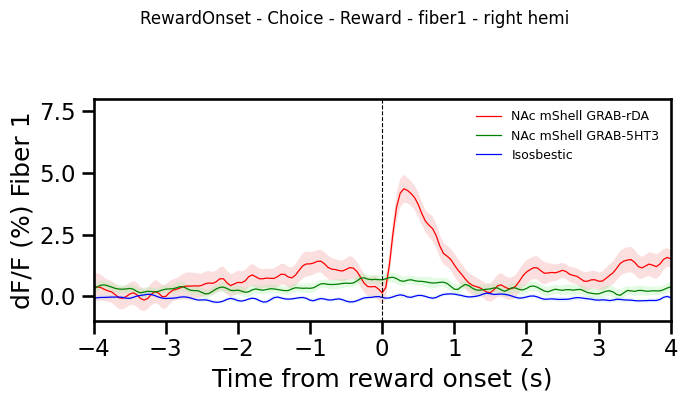

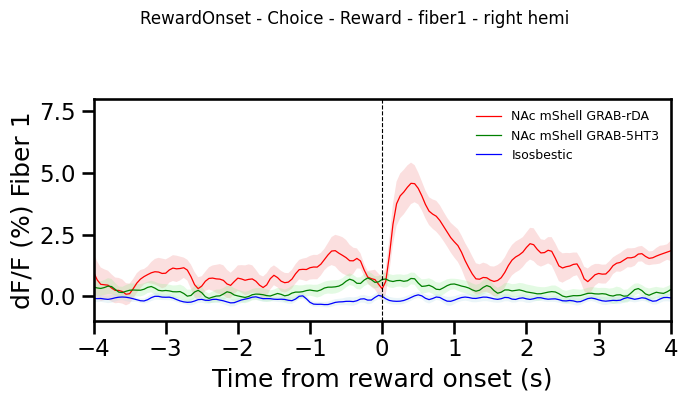

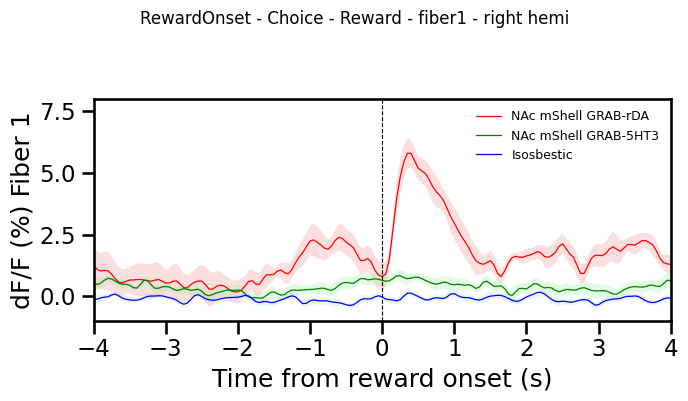

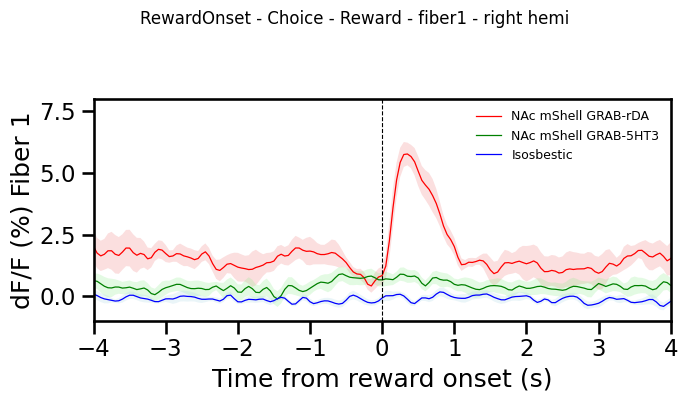

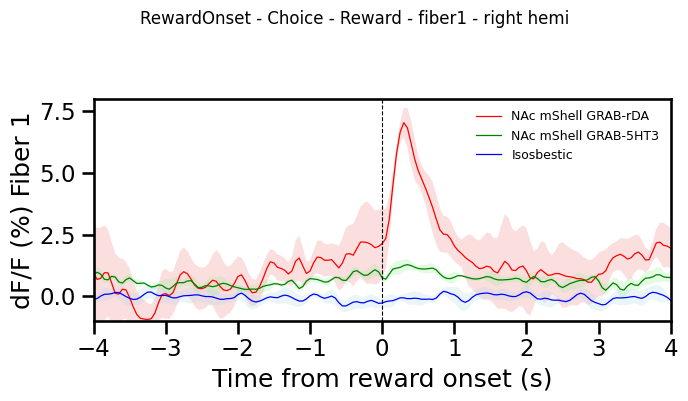

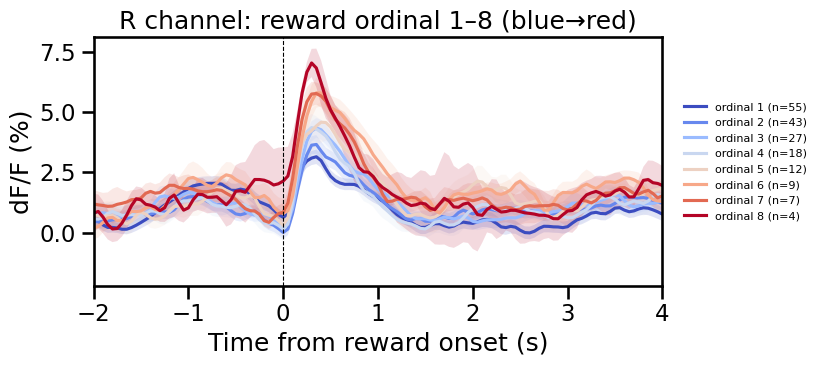

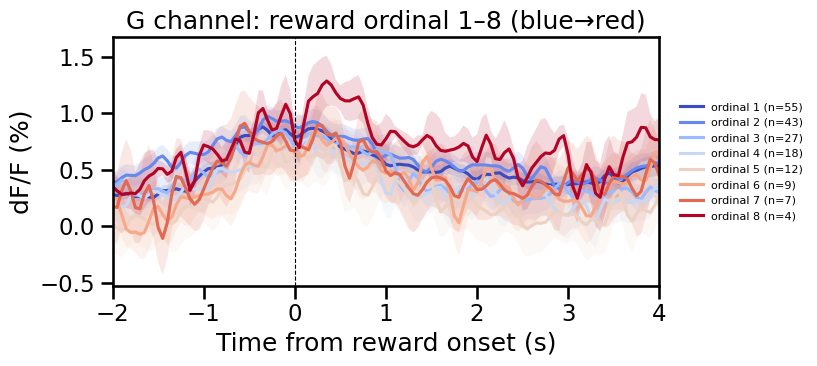

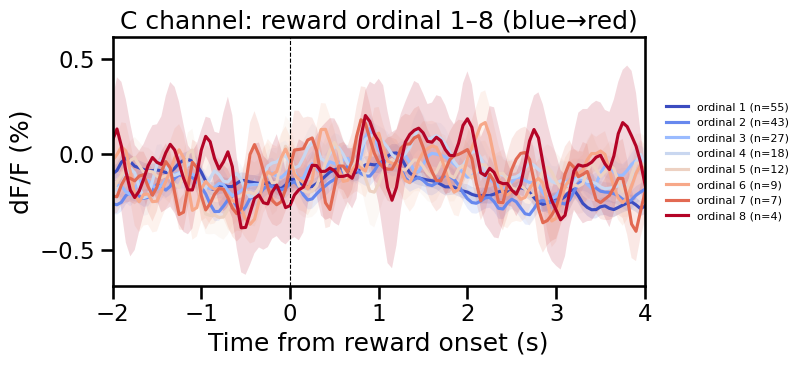

In [ ]:
##Reward Ordinal function

#Settings
alignment = "RewardOnset"
hemisphere = "Right"
save_ordinal_jpg = True

outdir = os.path.join("ordinal_plots", str(subject_ID))
os.makedirs(outdir, exist_ok=True)

def all_epochs_only_reward_ordinal(all_epochs, *, alignment="OdorSite", ordinal=1, is_reward=True):
    """
    Return a copy of all_epochs where only reward events with reward-ordinal==ordinal
    remain labeled as is_reward==True (others set False), so get_start_frames selects them.
    Uses patch_number + site_number columns already present.
    """
    ae = all_epochs.copy()

    align_cfg = ALIGNMENT_CFG[alignment]
    epoch_label = align_cfg["epoch_label"]
    

    # all rewarded choice events for this alignment
    mask_all = (
        (ae["label"] == epoch_label)
        & (ae["is_choice"].astype(bool))
        & (ae["is_reward"].astype(bool) == bool(is_reward))
    )

    # compute ordinal among *rewarded* events within each patch_number
    ev = ae.loc[mask_all, ["patch_number", "site_number"]].copy()
    ev = ev.sort_index()
    ev["reward_ordinal"] = ev.groupby("patch_number").cumcount() + 1

    mask_k = mask_all.copy()
    mask_k.loc[mask_all] = (ev["reward_ordinal"] == ordinal).values

    # For non-selected rewarded events, flip is_reward so get_start_frames ignores them
    ae.loc[mask_all & (~mask_k), "is_reward"] = (not is_reward)

    return ae, mask_k

# run ordinal 1-3
ordinal_results = {}

for k in [1, 2, 3, 4, 5, 6, 7, 8]:
    ae_k, mask_k = all_epochs_only_reward_ordinal(all_epochs, alignment="OdorSite", ordinal=k, is_reward=True)
    n_events = int(mask_k.sum())
    print(f"ordinal {k}: n_events = {n_events}")

    if n_events == 0:
        continue  # nothing to compute/plot for this ordinal

    res = plot_photometry_psth(
        ae_k,
        data1,
        Ctrl_dF_F,
        G_dF_F,
        R_dF_F,
        alignment=alignment,
        is_reward=True,
        subject=subject_ID,        
        hemisphere=hemisphere,    
        save_fig=False,
        xlims=(-4, 4),
        ylims=(-1, 8),
    )
    ordinal_results[k] = res


# ---- extract average traces (mean across trials) ----
# psth_* shape: (time, 1, trials)
t_rel = ordinal_results[1]["t_rel"]

avg = {}
sem = {}
for k, res in ordinal_results.items():
    avg[k] = {}
    sem[k] = {}
    for ch_name, psth in [("R", res["psth_R"]), ("G", res["psth_G"]), ("C", res["psth_C"])]:
        P = psth[:, 0, :]  # (time, trials)
        avg[k][ch_name] = np.nanmean(P, axis=1)
        sem[k][ch_name] = np.nanstd(P, axis=1, ddof=1) / np.sqrt(np.sum(~np.isnan(P), axis=1))

# ---- plot overlays: ordinal #1..#6 for each channel ----
import matplotlib as mpl
import matplotlib.pyplot as plt

ordinals_to_plot = [1, 2, 3, 4, 5, 6, 7, 8]

# Blue -> Red gradient (use "coolwarm"; you can also try "bwr")
cmap = mpl.cm.get_cmap("coolwarm")
norm = mpl.colors.Normalize(vmin=min(ordinals_to_plot), vmax=max(ordinals_to_plot))

# --- n trials per ordinal (count non-NaN trials) ---
# Uses the channel you're already plotting; choose one that's always present (R here).
n_trials = {}
for k, res in ordinal_results.items():
    P = res["psth_R"][:, 0, :]                 # (time, trials)
    n_trials[k] = int(np.sum(~np.isnan(P).all(axis=0)))  # trials with any non-NaN


for ch_name in ["R", "G", "C"]:
    fig, ax = plt.subplots(figsize=(11, 4))

    for k in ordinals_to_plot:
        if k not in avg:
            continue

        color = cmap(norm(k))
        label = f"ordinal {k} (n={n_trials.get(k, 0)})"
        ax.plot(t_rel, avg[k][ch_name], color=color, label=label)
        ax.fill_between(
            t_rel,
            avg[k][ch_name] - sem[k][ch_name],
            avg[k][ch_name] + sem[k][ch_name],
            color=color,
            alpha=0.15,
            linewidth=0,
        )

    ax.set_xlim(-2, 4)
    ax.axvline(0, color="k", ls="--", lw=0.8)
    ax.set_xlabel(ALIGNMENT_CFG.get(alignment, {}).get("xlabel", f"Time from {alignment} (s)"))
    ax.set_ylabel("dF/F (%)")
    ax.set_title(f"{ch_name} channel: reward ordinal 1–8 (blue→red)")

    # legend outside (right)
    ax.legend(
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=8,
    )

    # make room on the right for legend
    fig.tight_layout(rect=[0, 0, 0.78, 1])

    # save (optional)
    if save_ordinal_jpg:
        fname = f"m{subject_ID}_{session_date}_{hemisphere}_{alignment}_{ch_name}_ordinals.jpg"
        fig.savefig(os.path.join(outdir, fname), dpi=300, bbox_inches="tight")

    plt.show()


ordinal 1: n_events = 55
ordinal 2: n_events = 43
ordinal 3: n_events = 27
ordinal 4: n_events = 18
ordinal 5: n_events = 12
ordinal 6: n_events = 9
ordinal 7: n_events = 7
ordinal 8: n_events = 4


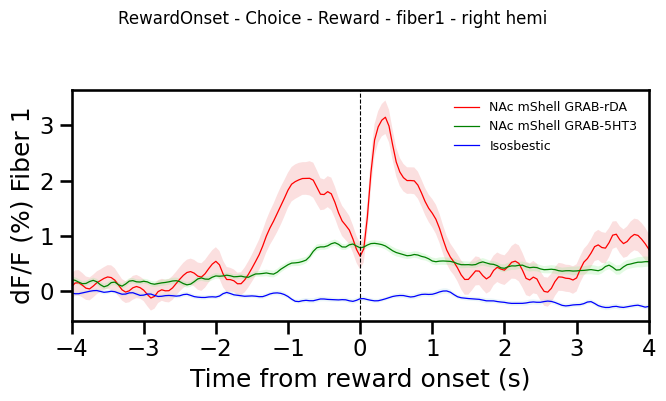

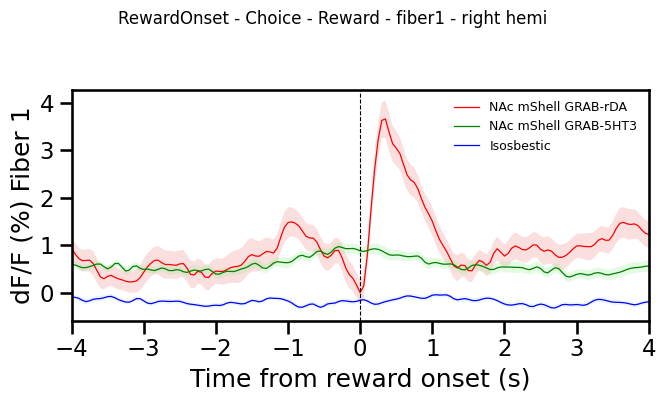

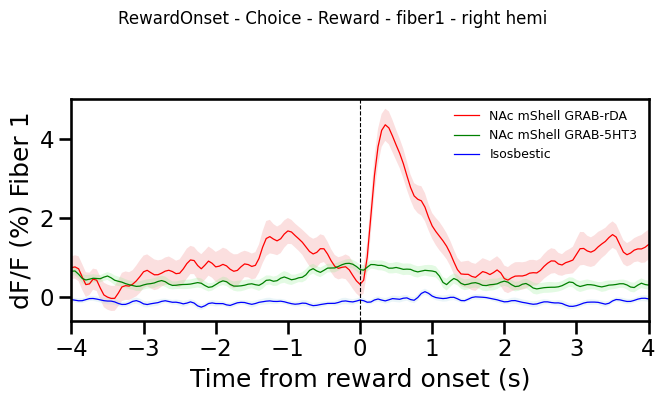

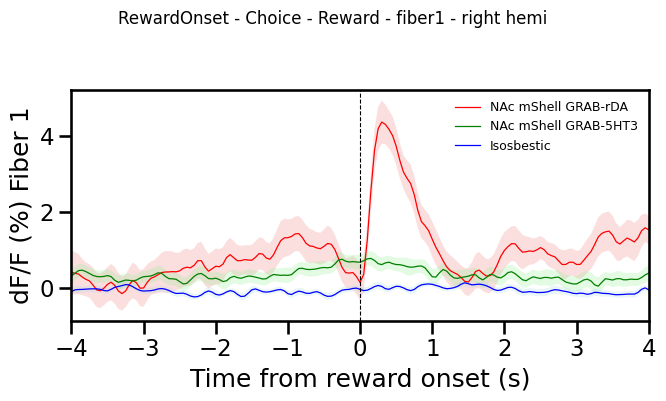

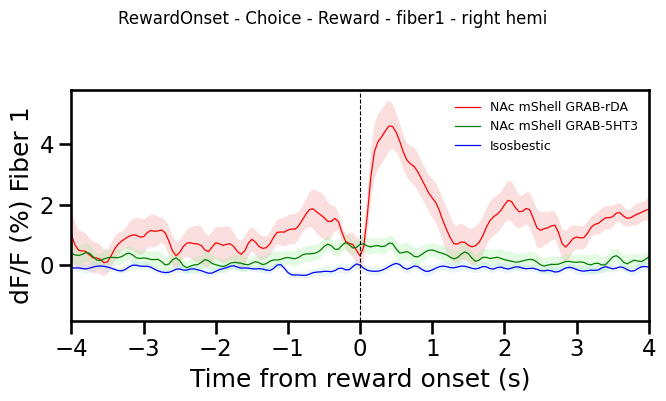

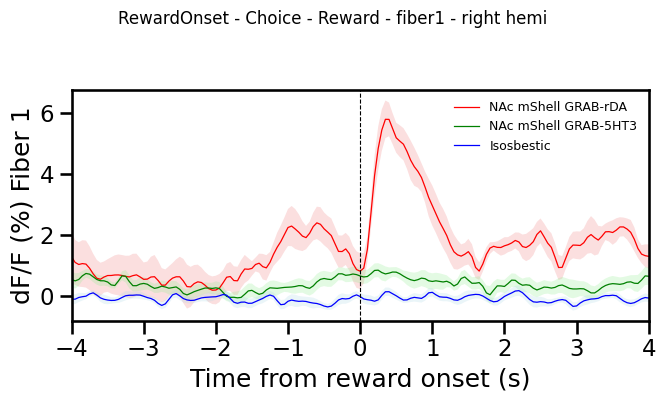

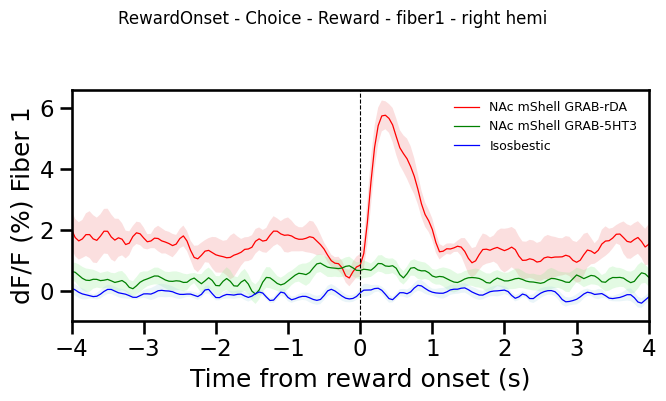

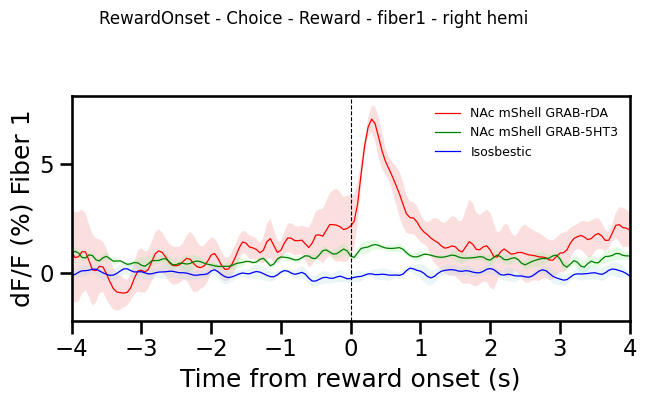

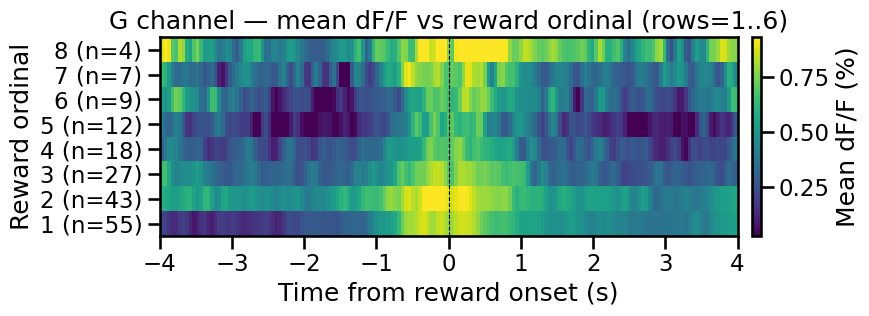

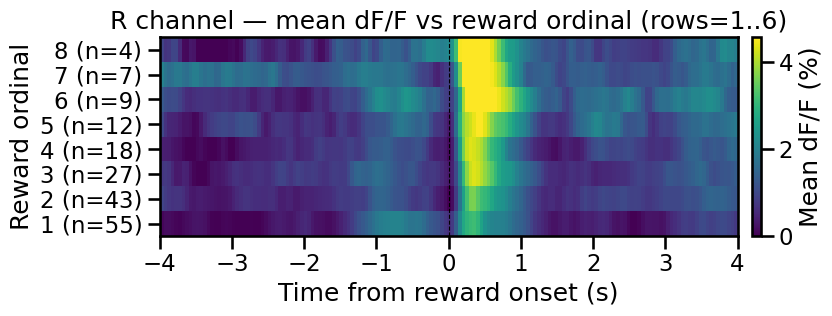

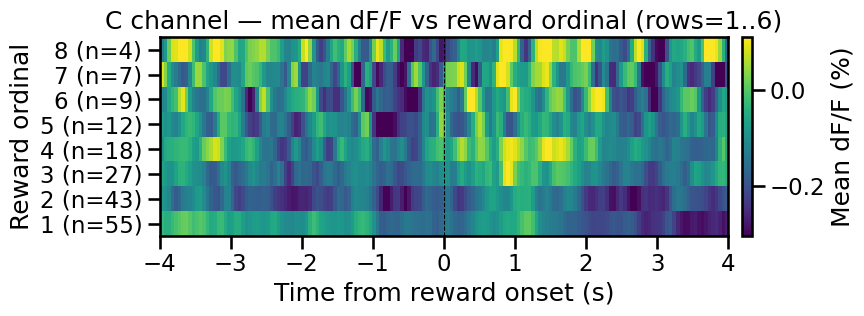

In [ ]:
#Heatmap Ordinals
# ----------------------------
# Settings
# ----------------------------
ordinals_to_plot = [1, 2, 3, 4, 5, 6, 7, 8]
xlims = (-4, 4)
alignment = "RewardOnset"
hemisphere = "Right"
subject = subject_ID
is_reward = True

# saving (match overlay logic)
save_ordinal_jpg = True
outdir = os.path.join("ordinal_plots", str(subject_ID))
os.makedirs(outdir, exist_ok=True)

# ----------------------------
# Helper: select only rewarded events of a given ordinal
# ----------------------------
def all_epochs_only_reward_ordinal(all_epochs, *, alignment="OdorSite", ordinal=1, is_reward=True):
    ae = all_epochs.copy()

    epoch_label = ALIGNMENT_CFG[alignment]["epoch_label"]

    mask_all = (
        (ae["label"] == epoch_label)
        & (ae["is_choice"].astype(bool))
        & (ae["is_reward"].astype(bool) == bool(is_reward))
    )

    ev = ae.loc[mask_all, ["patch_number", "site_number"]].copy().sort_index()
    ev["reward_ordinal"] = ev.groupby("patch_number").cumcount() + 1

    mask_k = mask_all.copy()
    mask_k.loc[mask_all] = (ev["reward_ordinal"] == ordinal).values

    # flip is_reward for non-selected events so get_start_frames ignores them
    ae.loc[mask_all & (~mask_k), "is_reward"] = (not is_reward)
    return ae, mask_k

# ----------------------------
# Pass 1: run PSTHs per ordinal, cache means
# ----------------------------
ordinal_results = {}
n_events_by_k = {}

for k in ordinals_to_plot:
    ae_k, mask_k = all_epochs_only_reward_ordinal(all_epochs, alignment=alignment, ordinal=k, is_reward=is_reward)
    n_events = int(mask_k.sum())
    n_events_by_k[k] = n_events
    print(f"ordinal {k}: n_events = {n_events}")

    if n_events == 0:
        continue

    res = plot_photometry_psth(
        ae_k, data1, Ctrl_dF_F, G_dF_F, R_dF_F,
        alignment=alignment,
        is_reward=is_reward,
        subject=subject,
        hemisphere=hemisphere,
        save_fig=False,
        xlims=xlims,
        ylims=None,   # heatmap will set its own scaling
    )
    ordinal_results[k] = res

# Require at least one ordinal to exist
if len(ordinal_results) == 0:
    raise ValueError("No ordinals had events; nothing to plot.")

# Timebase (assume consistent across ordinals)
t_rel = next(iter(ordinal_results.values()))["t_rel"]
t_rel = np.asarray(t_rel)

# columns within the requested xlims
tm = (t_rel >= xlims[0]) & (t_rel <= xlims[1])
t_plot = t_rel[tm]

# ----------------------------
# Build heatmap matrices: (6 rows, T cols) for each channel
# Each row is mean across trials at ROI-axis=0
# ----------------------------
def psth_to_mean_row(psth):
    """psth: (time, 1, trials) -> (time,) mean across trials"""
    P = np.asarray(psth)[:, 0, :]  # (time, trials)
    return np.nanmean(P, axis=1)

# allocate with NaNs for missing ordinals
heat = {ch: np.full((len(ordinals_to_plot), tm.sum()), np.nan, float) for ch in ["G", "R", "C"]}

for row_i, k in enumerate(ordinals_to_plot):
    if k not in ordinal_results:
        continue
    res = ordinal_results[k]
    heat["G"][row_i, :] = psth_to_mean_row(res["psth_G"])[tm]
    heat["R"][row_i, :] = psth_to_mean_row(res["psth_R"])[tm]
    heat["C"][row_i, :] = psth_to_mean_row(res["psth_C"])[tm]

# ----------------------------
# Plot: one heatmap per channel
# ----------------------------
xlabel = ALIGNMENT_CFG.get(alignment, {}).get("xlabel", f"Time from {alignment} (s)")

for ch in ["G", "R", "C"]:
    M = heat[ch]

    finite = M[np.isfinite(M)]
    if finite.size == 0:
        print(f"{ch}: no finite values; skipping")
        continue
    vmin, vmax = np.percentile(finite, [2, 98])

    fig, ax = plt.subplots(figsize=(9, 3.5))

    im = ax.imshow(
        M,
        aspect="auto",
        origin="lower",
        extent=[t_plot[0], t_plot[-1], 0.5, len(ordinals_to_plot) + 0.5],
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
    )

    ax.axvline(0, color="k", ls="--", lw=0.8)

    # alignment-aware xlabel
    ax.set_xlabel(xlabel)

    ax.set_ylabel("Reward ordinal")
    ax.set_yticks(ordinals_to_plot)

    # show event counts per ordinal on the y tick labels
    yticklabels = [f"{k} (n={n_events_by_k.get(k,0)})" for k in ordinals_to_plot]
    ax.set_yticklabels(yticklabels)

    ax.set_title(f"{ch} channel — mean dF/F vs reward ordinal (rows=1..6)")

    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label("Mean dF/F (%)")

    # make sure everything fits, especially colorbar, when saving
    fig.tight_layout()

    # save (optional) — Subject ID, date, hemisphere, alignment, color channel
    if save_ordinal_jpg:
        fname = f"m{subject}_{session_date}_{hemisphere}_{alignment}_{ch}_ordinals_heatmap.jpg"
        fig.savefig(os.path.join(outdir, fname), dpi=300, bbox_inches="tight")

    plt.show()


{'R': (0.0, 1.4024027004128041),
 'G': (0.0, 0.3414513324016623),
 'C': (-8.074349270001138e-18, 0.2445225858307846)}

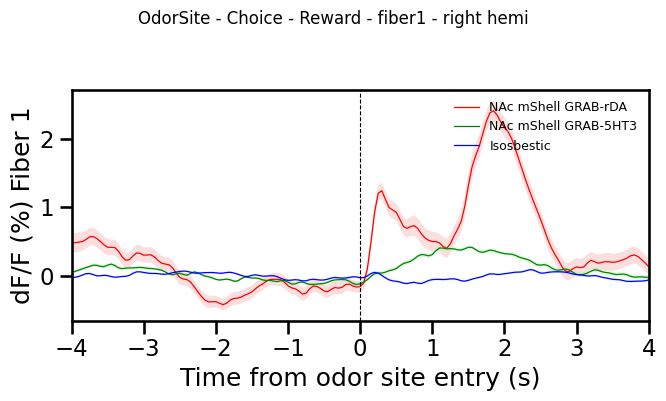

In [70]:
##Z-scored Ordinals

# --- Session-level baseline: pooled across ALL rewarded OdorSite trials ---
# assumes you have these variables already:
# all_epochs, data1, Ctrl_dF_F, G_dF_F, R_dF_F, subject_ID, hemisphere
# alignment (can be RewardOnset; baseline pool is still from rewarded OdorSite events)
# and you know preW/postW/fs used in plot_photometry_psth (defaults: preW=40, postW=200, fs=20)

preW = 80
postW = 200
fs = 20

# Make a "full rewarded OdorSite" PSTH using your same extraction path
res_all = plot_photometry_psth(
    all_epochs,
    data1,
    Ctrl_dF_F,
    G_dF_F,
    R_dF_F,
    alignment="OdorSite",     # baseline pool definition
    is_reward=True,
    subject=subject_ID,
    hemisphere=hemisphere,
    preW=preW,
    postW=postW,
    fs=fs,
    save_fig=False,
    xlims=(-4, 4),
    ylims=None,
)

base_slice = slice(0, preW)

def pooled_baseline_mu_sd(psth, base_slice):
    P = np.asarray(psth)[:, 0, :]              # (time, trials)
    base = P[base_slice, :].ravel()            # pool across time+trials
    mu = np.nanmean(base)
    sd = np.nanstd(base, ddof=1)
    return mu, sd

mu_sd = {}
for ch, key in [("R", "psth_R"), ("G", "psth_G"), ("C", "psth_C")]:
    mu, sd = pooled_baseline_mu_sd(res_all[key], base_slice)
    mu_sd[ch] = (mu, sd)

mu_sd  # dict like {"R": (mu, sd), ...}


ordinal 1: n_events = 55
ordinal 2: n_events = 43
ordinal 3: n_events = 27
ordinal 4: n_events = 18
ordinal 5: n_events = 12
ordinal 6: n_events = 9
ordinal 7: n_events = 7
ordinal 8: n_events = 4


C:\Users\jason.lee\AppData\Local\Temp\ipykernel_27644\69831036.py:102: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("coolwarm")


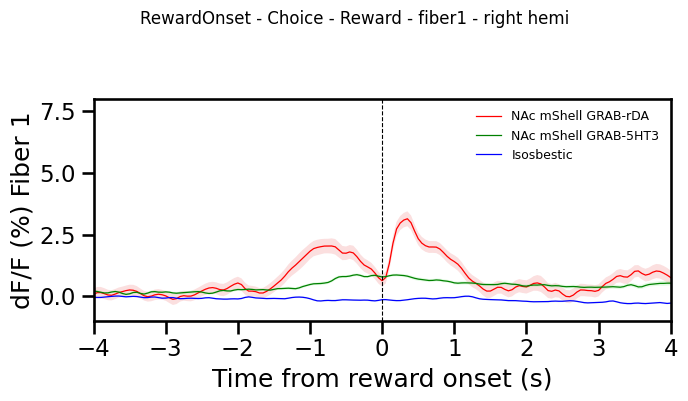

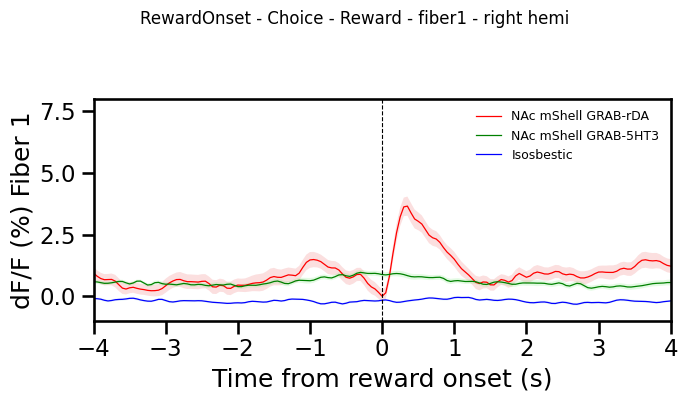

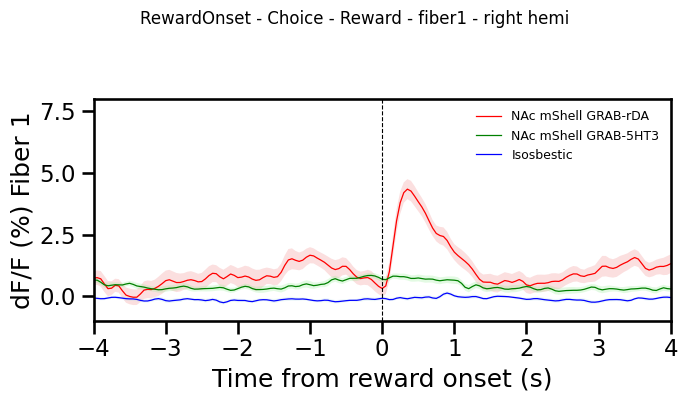

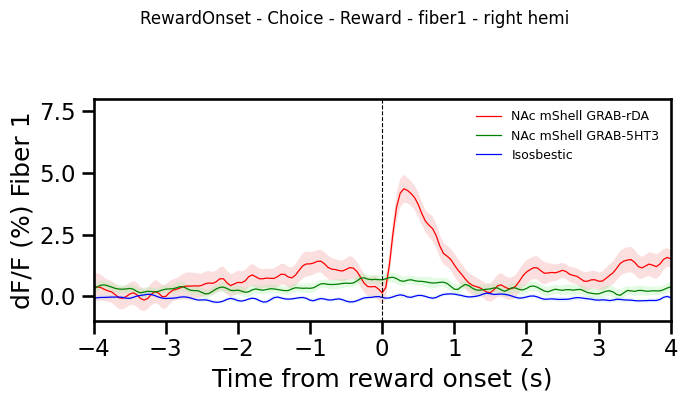

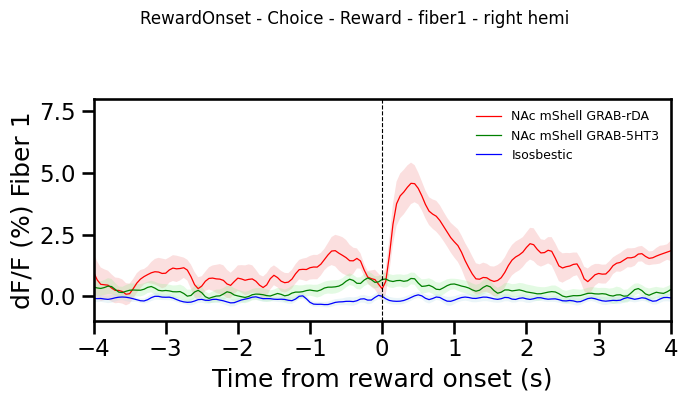

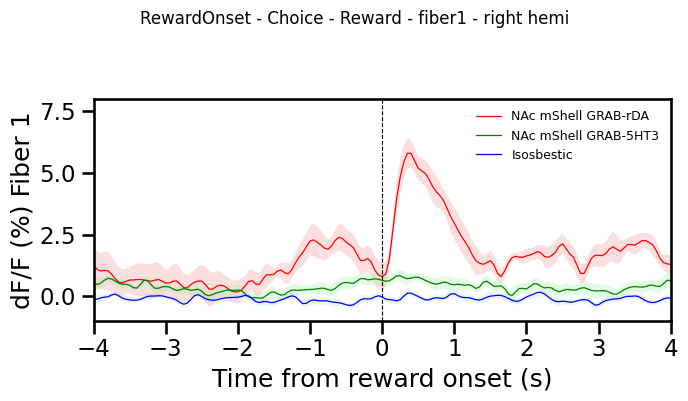

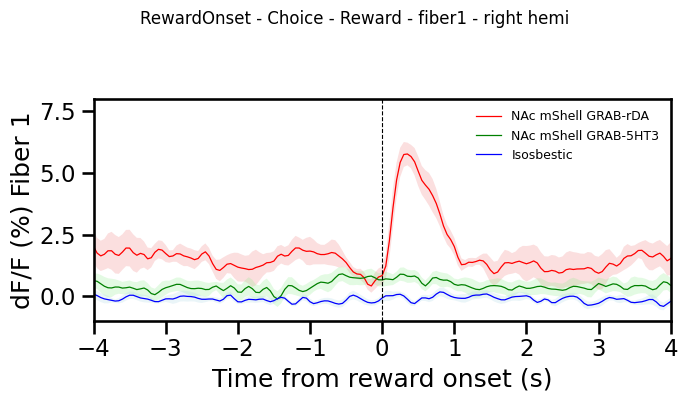

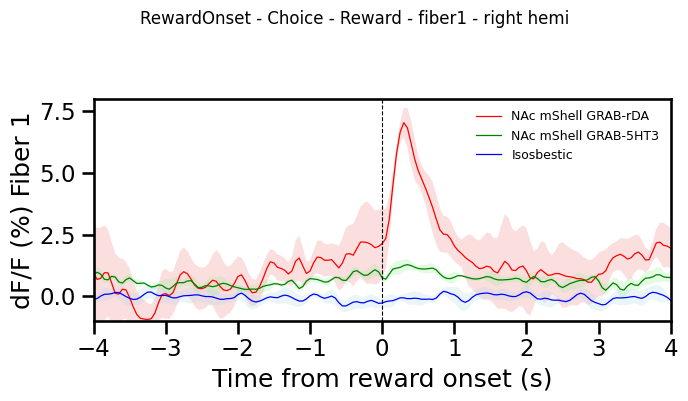

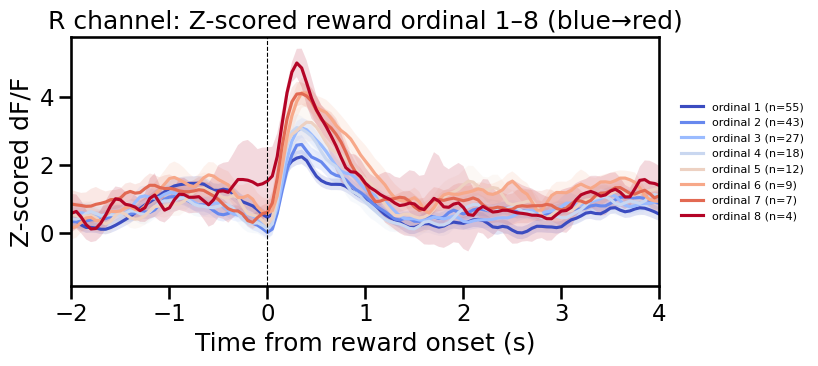

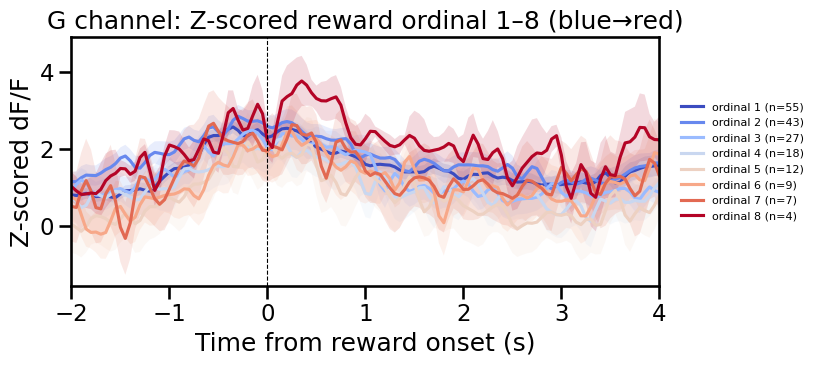

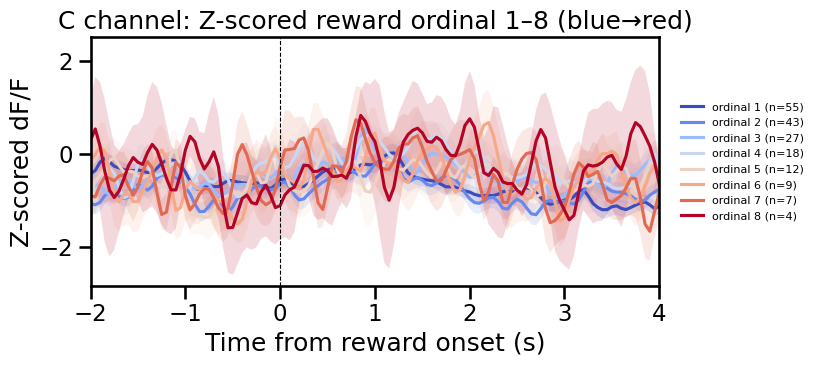

In [76]:
##z score ordinal 2

#Settings
alignment = "RewardOnset"
hemisphere = "Right"
save_ordinal_jpg = True

outdir = os.path.join("ordinal_plots", str(subject_ID))
os.makedirs(outdir, exist_ok=True)

def all_epochs_only_reward_ordinal_Zscored(all_epochs, *, alignment="OdorSite", ordinal=1, is_reward=True):
    """
    Return a copy of all_epochs where only reward events with reward-ordinal==ordinal
    remain labeled as is_reward==True (others set False), so get_start_frames selects them.
    Uses patch_number + site_number columns already present.
    """
    ae = all_epochs.copy()

    align_cfg = ALIGNMENT_CFG[alignment]
    epoch_label = align_cfg["epoch_label"]
    

    # all rewarded choice events for this alignment
    mask_all = (
        (ae["label"] == epoch_label)
        & (ae["is_choice"].astype(bool))
        & (ae["is_reward"].astype(bool) == bool(is_reward))
    )

    # compute ordinal among *rewarded* events within each patch_number
    ev = ae.loc[mask_all, ["patch_number", "site_number"]].copy()
    ev = ev.sort_index()
    ev["reward_ordinal"] = ev.groupby("patch_number").cumcount() + 1

    mask_k = mask_all.copy()
    mask_k.loc[mask_all] = (ev["reward_ordinal"] == ordinal).values

    # For non-selected rewarded events, flip is_reward so get_start_frames ignores them
    ae.loc[mask_all & (~mask_k), "is_reward"] = (not is_reward)

    return ae, mask_k

# run ordinal 1-3
ordinal_results = {}

for k in [1, 2, 3, 4, 5, 6, 7, 8]:
    ae_k, mask_k = all_epochs_only_reward_ordinal_Zscored(all_epochs, alignment="OdorSite", ordinal=k, is_reward=True)
    n_events = int(mask_k.sum())
    print(f"ordinal {k}: n_events = {n_events}")

    if n_events == 0:
        continue  # nothing to compute/plot for this ordinal

    res = plot_photometry_psth(
        ae_k,
        data1,
        Ctrl_dF_F,
        G_dF_F,
        R_dF_F,
        alignment=alignment,
        is_reward=True,
        subject=subject_ID,        
        hemisphere=hemisphere,    
        save_fig=False,
        xlims=(-4, 4),
        ylims=(-1, 8),
    )
    ordinal_results[k] = res


# ---- extract average traces (mean across trials) ----
# psth_* shape: (time, 1, trials)
t_rel = ordinal_results[1]["t_rel"]

avgZ = {}
semZ = {}

for k, res in ordinal_results.items():
    avgZ[k] = {}
    semZ[k] = {}

    for ch_name, psth_key in [("R", "psth_R"), ("G", "psth_G"), ("C", "psth_C")]:
        P = np.asarray(res[psth_key])[:, 0, :]          # (time, trials)

        mu, sd = mu_sd[ch_name]
        if (not np.isfinite(sd)) or (sd == 0):
            Z = P * np.nan
        else:
            Z = (P - mu) / sd

        avgZ[k][ch_name] = np.nanmean(Z, axis=1)
        semZ[k][ch_name] = np.nanstd(Z, axis=1, ddof=1) / np.sqrt(np.sum(~np.isnan(Z), axis=1))


# ---- plot overlays: ordinal #1..#6 for each channel ----
import matplotlib as mpl
import matplotlib.pyplot as plt

ordinals_to_plot = [1, 2, 3, 4, 5, 6, 7, 8]

# Blue -> Red gradient (use "coolwarm"; you can also try "bwr")
cmap = mpl.cm.get_cmap("coolwarm")
norm = mpl.colors.Normalize(vmin=min(ordinals_to_plot), vmax=max(ordinals_to_plot))

# --- n trials per ordinal (count non-NaN trials) ---
# Uses the channel you're already plotting; choose one that's always present (R here).
n_trials = {}
for k, res in ordinal_results.items():
    P = res["psth_R"][:, 0, :]                 # (time, trials)
    n_trials[k] = int(np.sum(~np.isnan(P).all(axis=0)))  # trials with any non-NaN


for ch_name in ["R", "G", "C"]:
    fig, ax = plt.subplots(figsize=(11, 4))

    for k in ordinals_to_plot:
        if k not in avgZ:
            continue

        color = cmap(norm(k))
        label = f"ordinal {k} (n={n_trials.get(k, 0)})"
        ax.plot(t_rel, avgZ[k][ch_name], color=color, label=label)
        ax.fill_between(
            t_rel,
            avgZ[k][ch_name] - semZ[k][ch_name],
            avgZ[k][ch_name] + semZ[k][ch_name],
            color=color,
            alpha=0.15,
            linewidth=0,
        )

    ax.set_xlim(-2, 4)
    ax.axvline(0, color="k", ls="--", lw=0.8)
    ax.set_xlabel(ALIGNMENT_CFG.get(alignment, {}).get("xlabel", f"Time from {alignment} (s)"))
    ax.set_ylabel("Z-scored dF/F")
    ax.set_title(f"{ch_name} channel: Z-scored reward ordinal 1–8 (blue→red)")

    # legend outside (right)
    ax.legend(
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=8,
    )

    # make room on the right for legend
    fig.tight_layout(rect=[0, 0, 0.78, 1])

    # save (optional)
    if save_ordinal_jpg:
        fname = f"m{subject_ID}_{session_date}_{hemisphere}_{alignment}_{ch_name}_ordinals.jpg"
        fig.savefig(os.path.join(outdir, fname), dpi=300, bbox_inches="tight")

    plt.show()

CUE  (0.5, 1.0)s: rewarded n=176 mean=1.47 sem=0.9107 | unrewarded n=128 mean=1.328 sem=1.015
REW  (1.5, 2.5)s: rewarded n=176 mean=14.54 sem=1.126 | unrewarded n=128 mean=-2.934 sem=1.151
Cue window (0.5, 1.0): Welch t=0.105, p=0.917 (nR=176, nU=128)
Rew window (1.5, 2.5): Welch t=10.9, p=2.8e-23 (nR=176, nU=128)


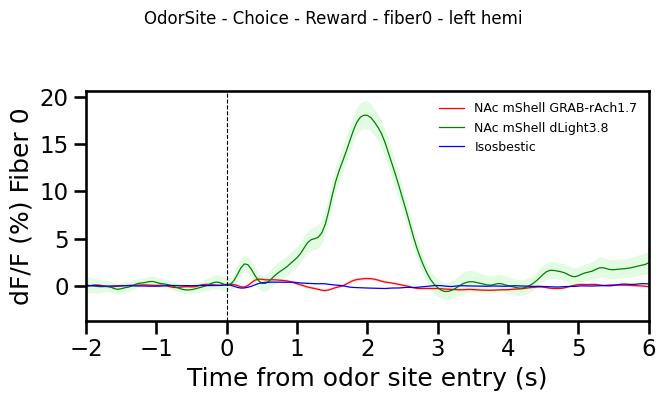

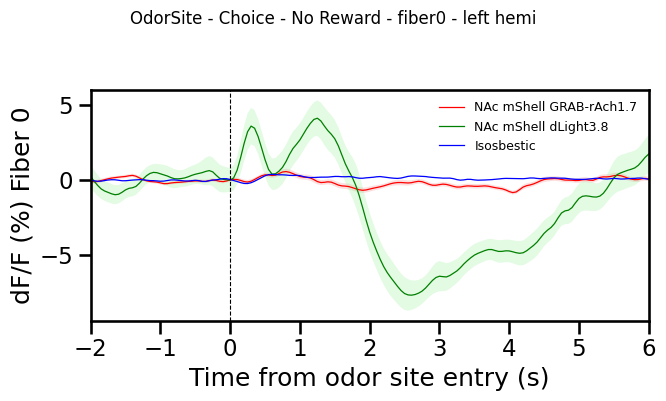

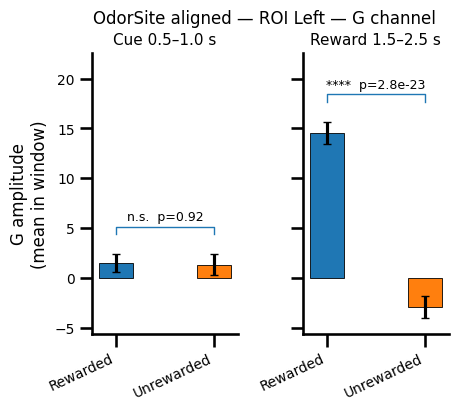

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# SETTINGS
# =========================
ALIGNMENT = "OdorSite"      # whatever you used for PSTH alignment
CUE_WIN = (0.5, 1.0)
REW_WIN = (1.5, 2.5)

SUBJECT = 788731
HEMISPHERE = "Left"
XLIMS = (-2, 6)
YLIMS = None

CHANNEL = "G"               # "G" or "R" or "C"

# =========================
# Helpers
# =========================

def window_mean_per_trial(t_rel, X_time_by_trials, win):
    """Return per-trial mean in time window win=(t0,t1)."""
    t_rel = np.asarray(t_rel, float).squeeze()
    X = np.asarray(X_time_by_trials, float)
    mask = (t_rel >= win[0]) & (t_rel <= win[1])
    if mask.sum() < 2:
        raise ValueError(f"Window {win} has too few samples. Check t_rel range: {t_rel.min()}..{t_rel.max()}")
    return np.nanmean(X[mask, :], axis=0)  # (trials,)

def mean_sem(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan, np.nan, 0
    m = np.mean(x)
    se = np.std(x, ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0
    return m, se, len(x)

# =========================
# 1) Run PSTH for rewarded vs unrewarded
# =========================
res_rew = plot_photometry_psth(
    all_epochs, data1, Ctrl_dF_F, G_dF_F, R_dF_F,
    alignment=ALIGNMENT, is_reward=True,
    subject=SUBJECT, hemisphere=HEMISPHERE,
    save_fig=False, xlims=XLIMS, ylims=YLIMS
)

res_unr = plot_photometry_psth(
    all_epochs, data1, Ctrl_dF_F, G_dF_F, R_dF_F,
    alignment=ALIGNMENT, is_reward=False,
    subject=SUBJECT, hemisphere=HEMISPHERE,
    save_fig=False, xlims=XLIMS, ylims=YLIMS
)

t_rel = res_rew["t_rel"]

# pick channel
key = {"G": "psth_G", "R": "psth_R", "C": "psth_C"}[CHANNEL]
X_rew = (res_rew[key])[:,0,:]
X_unr = (res_unr[key])[:,0,:]

# =========================
# 2) Compute per-trial window amplitudes
# =========================
cue_rew = window_mean_per_trial(t_rel, X_rew, CUE_WIN)
cue_unr = window_mean_per_trial(t_rel, X_unr, CUE_WIN)

rew_rew = window_mean_per_trial(t_rel, X_rew, REW_WIN)
rew_unr = window_mean_per_trial(t_rel, X_unr, REW_WIN)

# summary stats
cue_rew_m, cue_rew_se, n1 = mean_sem(cue_rew)
cue_unr_m, cue_unr_se, n2 = mean_sem(cue_unr)
rew_rew_m, rew_rew_se, n3 = mean_sem(rew_rew)
rew_unr_m, rew_unr_se, n4 = mean_sem(rew_unr)

print(f"CUE  {CUE_WIN}s: rewarded n={n1} mean={cue_rew_m:.4g} sem={cue_rew_se:.4g} | unrewarded n={n2} mean={cue_unr_m:.4g} sem={cue_unr_se:.4g}")
print(f"REW  {REW_WIN}s: rewarded n={n3} mean={rew_rew_m:.4g} sem={rew_rew_se:.4g} | unrewarded n={n4} mean={rew_unr_m:.4g} sem={rew_unr_se:.4g}")

from scipy import stats
import numpy as np

def welch_ttest(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    a = a[np.isfinite(a)]; b = b[np.isfinite(b)]
    t, p = stats.ttest_ind(a, b, equal_var=False)
    return t, p, len(a), len(b)

def p_to_stars(p):
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 5e-2: return "*"
    return "n.s."

# Cue window stats
t_cue, p_cue, ncue_r, ncue_u = welch_ttest(cue_rew, cue_unr)
# Reward window stats
t_rew, p_rew, nrew_r, nrew_u = welch_ttest(rew_rew, rew_unr)

print(f"Cue window {CUE_WIN}: Welch t={t_cue:.3g}, p={p_cue:.3g} (nR={ncue_r}, nU={ncue_u})")
print(f"Rew window {REW_WIN}: Welch t={t_rew:.3g}, p={p_rew:.3g} (nR={nrew_r}, nU={nrew_u})")

# =========================
# 3) Bar plots (mean ± SEM) — skinnier + different colors
# =========================
labels = ["Rewarded", "Unrewarded"]

# skinny look
BAR_W = 0.28
CAP = 3
ROT = 25

# choose two distinct colors (edit if you want)
COL_REW = "tab:blue"
COL_UNR = "tab:orange"

fig, axes = plt.subplots(
    1, 2,
    figsize=(4.6, 3.8),   # <-- much skinnier overall
    sharey=True
)

# positions (keep some gap)
x = np.array([0.0, 0.8])

# Cue window
axes[0].bar(
    x,
    [cue_rew_m, cue_unr_m],
    yerr=[cue_rew_se, cue_unr_se],
    width=BAR_W,
    capsize=CAP,
    color=[COL_REW, COL_UNR],
    edgecolor="k",
    linewidth=0.6
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=ROT, ha="right")
axes[0].set_title(f"Cue {CUE_WIN[0]}–{CUE_WIN[1]} s", fontsize=11)
axes[0].set_ylabel(f"{CHANNEL} amplitude\n(mean in window)", fontsize=12)

def p_to_stars(p):
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 5e-2: return "*"
    return "n.s."

def add_sig(ax, x1, x2, y_top_of_bars, yr, p, lift_frac=0.10, h_frac=0.04, text_frac=0.015):
    """
    Draw bracket + single-line annotation above bars without clipping.

    y_top_of_bars: max(mean+SEM) for the bars in THIS subplot
    yr: y-range (shared for both axes)
    lift_frac: how far above bars to place bracket bottom (fraction of yr)
    h_frac: bracket height (fraction of yr)
    text_frac: text gap above bracket (fraction of yr)
    """
    y_base = y_top_of_bars + lift_frac * yr
    h = h_frac * yr

    ax.plot([x1, x1, x2, x2], [y_base, y_base+h, y_base+h, y_base], lw=1)

    ax.text((x1+x2)/2, y_base+h + text_frac*yr,
            f"{p_to_stars(p)}  p={p:.2g}",
            ha="center", va="bottom", fontsize=9)

# ---- set y-lims once so nothing clips (works well with sharey=True) ----
ymax_data = np.nanmax([
    cue_rew_m + cue_rew_se, cue_unr_m + cue_unr_se,
    rew_rew_m + rew_rew_se, rew_unr_m + rew_unr_se
])
ymin_data = np.nanmin([
    cue_rew_m - cue_rew_se, cue_unr_m - cue_unr_se,
    rew_rew_m - rew_rew_se, rew_unr_m - rew_unr_se
])
yr = (ymax_data - ymin_data) if (np.isfinite(ymax_data - ymin_data) and ymax_data > ymin_data) else 1.0

TOP_PAD = 0.35 * yr   # enough for bracket+text
BOT_PAD = 0.08 * yr
for ax in axes:
    ax.set_ylim(ymin_data - BOT_PAD, ymax_data + TOP_PAD)

# ---- add sig to each subplot using its own tallest bar height ----
cue_top = np.nanmax([cue_rew_m + cue_rew_se, cue_unr_m + cue_unr_se])
rew_top = np.nanmax([rew_rew_m + rew_rew_se, rew_unr_m + rew_unr_se])

add_sig(axes[0], x[0], x[1], cue_top, yr, p_cue)
add_sig(axes[1], x[0], x[1], rew_top, yr, p_rew)


# After you draw the cue bars:
ymax0 = np.nanmax([cue_rew_m + cue_rew_se, cue_unr_m + cue_unr_se])
ymin0 = np.nanmin([cue_rew_m - cue_rew_se, cue_unr_m - cue_unr_se])
rng0 = (ymax0 - ymin0) if ymax0 > ymin0 else 1.0

# Reward window
axes[1].bar(
    x,
    [rew_rew_m, rew_unr_m],
    yerr=[rew_rew_se, rew_unr_se],
    width=BAR_W,
    capsize=CAP,
    color=[COL_REW, COL_UNR],
    edgecolor="k",
    linewidth=0.6
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=ROT, ha="right")
axes[1].set_title(f"Reward {REW_WIN[0]}–{REW_WIN[1]} s", fontsize=11)

# After you draw the reward bars:
ymax1 = np.nanmax([rew_rew_m + rew_rew_se, rew_unr_m + rew_unr_se])
ymin1 = np.nanmin([rew_rew_m - rew_rew_se, rew_unr_m - rew_unr_se])
rng1 = (ymax1 - ymin1) if ymax1 > ymin1 else 1.0

# aesthetics
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=10)

# --- titles ---
fig.suptitle(f"{ALIGNMENT} aligned — ROI {HEMISPHERE} — {CHANNEL} channel", y=0.965, fontsize=12)

# --- tighten the vertical spacing between suptitle and subplot titles ---
fig.subplots_adjust(top=0.85, wspace=0.45)  # top controls the gap; increase top -> less gap

# If you also use tight_layout, use it FIRST with a rect, then subplots_adjust LAST:
# plt.tight_layout(rect=[0, 0, 1, 0.92])
# fig.subplots_adjust(top=0.86, wspace=0.45)




Shared y-lims: (-30, 50)


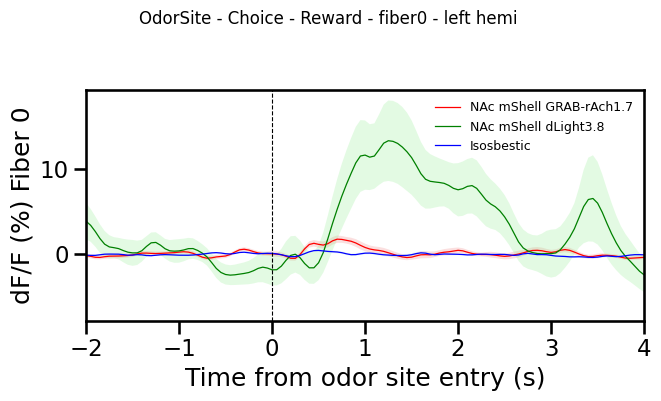

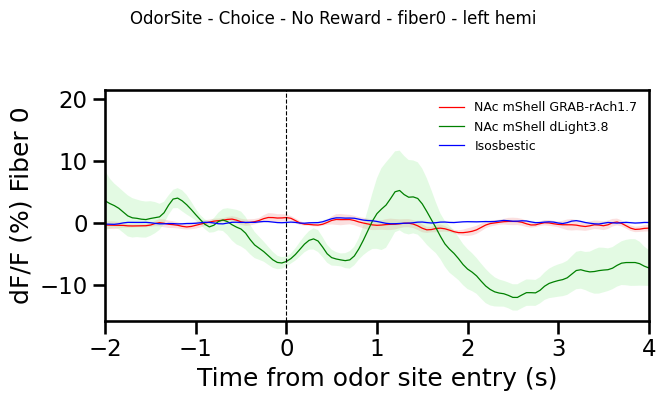

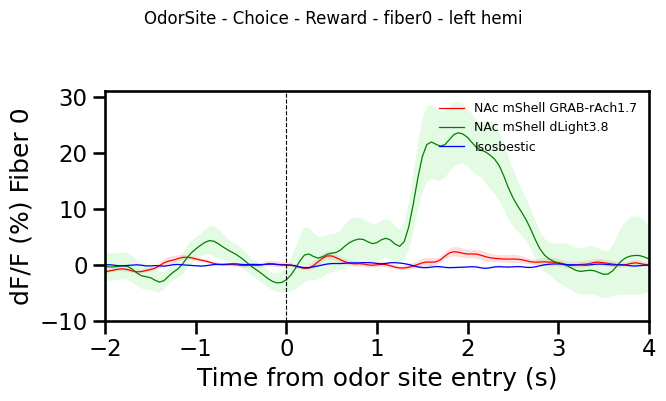

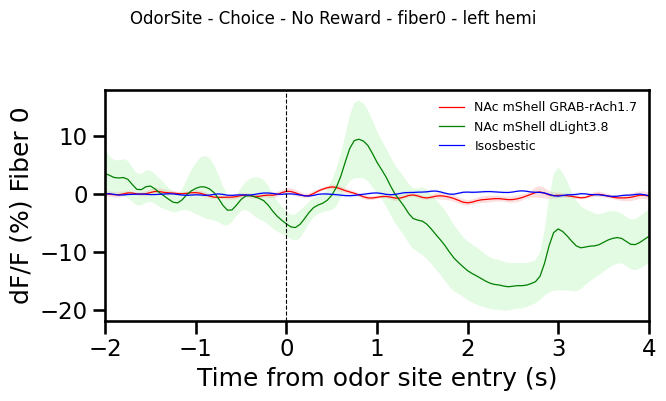

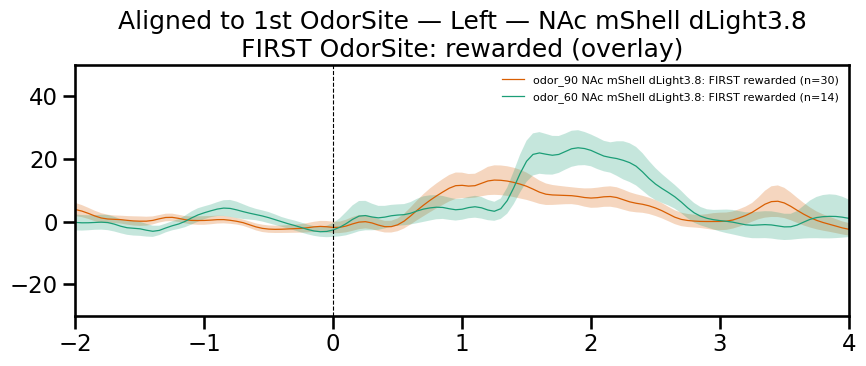

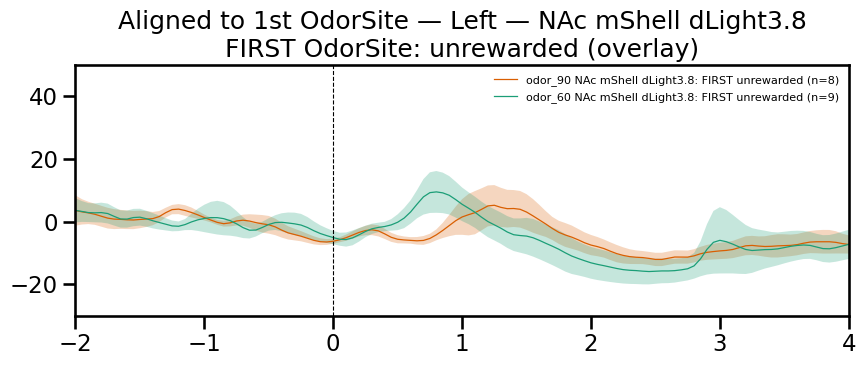

In [ ]:
#Odor60 vs Odor90
# ============================
# SETTINGS
# ============================
ODORS = ["odor_90", "odor_60"]
XLIMS = (-2, 4)

# Pick which hemisphere + which photometry channel to plot
HEMISPHERE = "Left"          # "Left" or "Right"
CHANNEL = "G"                 # "G", "R", or "C" (if your plotter returns Ctrl)

SUBJECT = subject_ID

# Padding fraction for shared y-lims
YLIM_PAD_FRAC = 0.05

# OPTIONAL: if you want to hard-set ylims, set to tuple like (-3, 4), else None
FORCE_YLIMS = (-30,50)  # e.g. (-3, 4)

# ============================
# Color key (odor_60 vs odor_90)
# ============================
color1 = "#d95f02"
color2 = "#1b9e77"
color3 = "#7570b3"
color4 = "#e7298a"

color_dict_label = {
    "InterSite": "#808080",
    "InterPatch": "#b3b3b3",
    "PatchZ": "#d95f02",
    "PatchZA": "#d95f02",
    "PatchZB": "#d95f02",
    "PatchB": "#d95f02",
    "PatchA": "#7570b3",
    "PatchC": "#1b9e77",
    "Alpha-pinene": "#1b9e77",
    "Methyl Butyrate": "#7570b3",
    "Amyl Acetate": "#d95f02",
    "Fenchone": "#7570b3",
    "Dipropyl sulfide": "#7570b3",
    "Dypropil sulfide": "#7570b3",
    "Hexanal": "#1b9e77",
    "Pentyl acetate": "#d95f02",
    "S": color1,
    "D": color2,
    "N": color3,
    "Do": color1,
    "None": color4,
    "odor_0": color3,
    "odor_60": color2,
    "odor_90": color1,
    "odor_fast": "#d95f02",
    "odor_slow": "#1b9e77",
    "A": color1,
    "B": color2,
    "C": color3,
    "OdorA": color1,
    "OdorB": color2,
    "OdorC": color3,
}

# ============================
# Helpers
# ============================
def odor_mask_from_patch_label(ae: pd.DataFrame, odor_name: str) -> pd.Series:
    if "patch_label" not in ae.columns:
        raise KeyError("Expected odor identity in all_epochs['patch_label'], but that column is missing.")
    return ae["patch_label"].astype(str) == odor_name

def first_odorsite_mask(ae: pd.DataFrame) -> pd.Series:
    if "patch_number" not in ae.columns:
        raise KeyError("all_epochs must contain 'patch_number'.")

    odor_rows = (ae["label"] == "OdorSite") & ae["patch_number"].notna()
    out = pd.Series(False, index=ae.index)

    if "site_number" in ae.columns:
        mins = ae.loc[odor_rows].groupby("patch_number")["site_number"].transform("min")
        out.loc[odor_rows] = (ae.loc[odor_rows, "site_number"] == mins).values
        return out

    tmp = ae.loc[odor_rows, ["patch_number"]].copy()
    tmp["t"] = ae.loc[odor_rows].index.values.astype(float)
    tmin = tmp.groupby("patch_number")["t"].transform("min")
    out.loc[odor_rows] = (tmp["t"] == tmin).values
    return out

def robust_min_max(x):
    x = np.asarray(x, float)
    if x.size == 0 or np.all(np.isnan(x)):
        return None, None
    return float(np.nanmin(x)), float(np.nanmax(x))

def get_channel_trials(res: dict, channel: str) -> np.ndarray:
    """
    Returns array shaped (T, Ntrials) for selected channel from plot_photometry_psth result dict.
    Expects res keys like 'psth_G', 'psth_R', 'psth_Ctrl' or 'psth_C' depending on your function.
    """
    ch = channel.upper()
    key_map = {
        "G": ["psth_G"],
        "R": ["psth_R"],
        "C": ["psth_C", "psth_Ctrl", "psth_Ctrl_dF_F", "psth_CtrlDF_F"],
    }
    if ch not in key_map:
        raise ValueError(f"CHANNEL must be one of {list(key_map.keys())}, got {channel!r}")

    for k in key_map[ch]:
        if k in res:
            arr = np.asarray(res[k])
            # expected shape (T, n_roi, n_trials) -> take ROI 0
            return arr[:, 0, :]

    raise KeyError(f"Could not find a PSTH key for CHANNEL={channel!r}. Tried: {key_map[ch]}")

# ============================
# Build cache per odor (rewarded + unrewarded)
# ============================
cache = {}  # odor_name -> dict(t_rel, rew(T,N), unr(T,N))
global_min = np.inf
global_max = -np.inf

ae0 = all_epochs.sort_index().copy()

for odor_name in ODORS:
    ae = ae0.copy()

    m_odor = odor_mask_from_patch_label(ae, odor_name)
    m_first_all = first_odorsite_mask(ae)
    m_first = m_first_all & m_odor

    # Keep only FIRST odorsite for this odor as "OdorSite"; relabel other OdorSite rows so they won't align
    ae.loc[(ae["label"] == "OdorSite") & (~m_first), "label"] = "OdorSite_other"

    res_rew = plot_photometry_psth(
        ae, data1, Ctrl_dF_F, G_dF_F, R_dF_F,
        alignment="OdorSite", is_reward=True,
        subject=SUBJECT, hemisphere=HEMISPHERE,
        save_fig=False, xlims=XLIMS, ylims=None,
    )
    res_unr = plot_photometry_psth(
        ae, data1, Ctrl_dF_F, G_dF_F, R_dF_F,
        alignment="OdorSite", is_reward=False,
        subject=SUBJECT, hemisphere=HEMISPHERE,
        save_fig=False, xlims=XLIMS, ylims=None,
    )

    t_rel = res_rew["t_rel"]
    ch_rew = get_channel_trials(res_rew, CHANNEL)  # (T, N)
    ch_unr = get_channel_trials(res_unr, CHANNEL)  # (T, N)

    cache[odor_name] = dict(t_rel=t_rel, rew=ch_rew, unr=ch_unr)

    for arr in (ch_rew, ch_unr):
        mn, mx = robust_min_max(arr)
        if mn is None:
            continue
        global_min = min(global_min, mn)
        global_max = max(global_max, mx)

if not np.isfinite(global_min) or not np.isfinite(global_max):
    raise ValueError("Could not compute shared y-lims (all traces empty/NaN).")

pad = YLIM_PAD_FRAC * (global_max - global_min + 1e-9)
SHARED_YLIMS = (global_min - pad, global_max + pad)
if FORCE_YLIMS is not None:
    SHARED_YLIMS = FORCE_YLIMS

print("Shared y-lims:", SHARED_YLIMS)

# ============================
# Labels for chosen hemisphere/channel
# ============================
try:
    cfg = SUBJECT_CFG[SUBJECT][HEMISPHERE]
    g_label = cfg.get("G_label", "Green")
    r_label = cfg.get("R_label", "Red")
    c_label = cfg.get("C_label", cfg.get("Ctrl_label", "Isosbestic"))
except Exception:
    g_label, r_label, c_label = "Green", "Red", "Isosbestic"

channel_label_map = {"G": g_label, "R": r_label, "C": c_label}
CH_LABEL = channel_label_map.get(CHANNEL.upper(), CHANNEL.upper())

# ============================
# Overlay plots:
#   1) Rewarded: odor_90 vs odor_60 overlaid
#   2) Unrewarded: odor_90 vs odor_60 overlaid
# ============================
odor_a, odor_b = ODORS[0], ODORS[1]
t_rel_a = cache[odor_a]["t_rel"]
t_rel_b = cache[odor_b]["t_rel"]

# If t_rel differs slightly between odors, we still plot each with its own x; usually they match.
# (If you want to enforce identical t_rel, assert np.allclose(t_rel_a, t_rel_b).)

col_a = color_dict_label.get(odor_a, "k")
col_b = color_dict_label.get(odor_b, "0.5")

plt.figure(figsize=(9, 4))
plot_mean_sem(t_rel_a, cache[odor_a]["rew"], col_a, col_a, f"{odor_a} {CH_LABEL}: FIRST rewarded (n={cache[odor_a]['rew'].shape[1]})")
plot_mean_sem(t_rel_b, cache[odor_b]["rew"], col_b, col_b, f"{odor_b} {CH_LABEL}: FIRST rewarded (n={cache[odor_b]['rew'].shape[1]})")
plt.axvline(0, color="k", ls="--", lw=0.8)
plt.xlim(*XLIMS)
plt.ylim(*SHARED_YLIMS)
plt.title(f"Aligned to 1st OdorSite — {HEMISPHERE} — {CH_LABEL}\nFIRST OdorSite: rewarded (overlay)")
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
plot_mean_sem(t_rel_a, cache[odor_a]["unr"], col_a, col_a, f"{odor_a} {CH_LABEL}: FIRST unrewarded (n={cache[odor_a]['unr'].shape[1]})")
plot_mean_sem(t_rel_b, cache[odor_b]["unr"], col_b, col_b, f"{odor_b} {CH_LABEL}: FIRST unrewarded (n={cache[odor_b]['unr'].shape[1]})")
plt.axvline(0, color="k", ls="--", lw=0.8)
plt.xlim(*XLIMS)
plt.ylim(*SHARED_YLIMS)
plt.title(f"Aligned to 1st OdorSite — {HEMISPHERE} — {CH_LABEL}\nFIRST OdorSite: unrewarded (overlay)")
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()


In [39]:
import numpy as np
import pandas as pd

def get_patch_start_leave_for_high_reward_patches(
    all_epochs: pd.DataFrame,
    *,
    reward_epoch_label: str = "OdorSite",
    min_rewarded_sites: int = 7,
    require_choice: bool = True,
    start_mode: str = "first_in_patch",   # "first_in_patch" or "first_reward_epoch"
    leave_mode: str = "next_timestamp",   # "next_timestamp" or "last_in_patch"
) -> pd.DataFrame:
    """
    Return patch start + patch leave timestamps for patches that contain >= min_rewarded_sites
    rewarded sites (counted among `reward_epoch_label` rows, optionally requiring is_choice).

    Assumes:
      - all_epochs is time-sorted by index (timestamps). If not, we sort by index.
      - all_epochs has columns: "patch_number", "label", "is_reward" (+ optionally "is_choice")

    Definitions:
      - rewarded site = row with label == reward_epoch_label and is_reward == True
        and (if require_choice) is_choice == True.

    patch_start_time:
      - start_mode="first_in_patch": first timestamp in all_epochs for that patch_number
      - start_mode="first_reward_epoch": first timestamp among reward_epoch_label rows in that patch

    patch_leave_time:
      - leave_mode="next_timestamp": timestamp of the first row *after* the last row in the patch
        (NaN if patch is last in session)
      - leave_mode="last_in_patch": timestamp of the last row in the patch
    """
    ae = all_epochs.sort_index()

    if "patch_number" not in ae.columns:
        raise KeyError("all_epochs must contain a 'patch_number' column.")
    if "label" not in ae.columns:
        raise KeyError("all_epochs must contain a 'label' column.")
    if "is_reward" not in ae.columns:
        raise KeyError("all_epochs must contain an 'is_reward' column.")
    if require_choice and "is_choice" not in ae.columns:
        raise KeyError("require_choice=True but all_epochs has no 'is_choice' column.")

    # mask for rewarded sites within patches
    mask_reward = (ae["label"] == reward_epoch_label) & (ae["is_reward"].astype(bool))
    if require_choice:
        mask_reward &= ae["is_choice"].astype(bool)

    # count rewarded sites per patch_number
    rewarded_counts = ae.loc[mask_reward].groupby("patch_number").size()
    keep_patches = rewarded_counts[rewarded_counts >= min_rewarded_sites]

    if keep_patches.empty:
        return pd.DataFrame(
            columns=[
                "patch_number",
                "n_rewarded_sites",
                "patch_start_time",
                "patch_leave_time",
                "patch_duration",
            ]
        )

    # precompute first/last timestamp per patch_number (from all rows in patch)
    grp = ae.groupby("patch_number", sort=False)
    first_in_patch = grp.apply(lambda g: g.index[0])
    last_in_patch  = grp.apply(lambda g: g.index[-1])

    # compute leave time as "next timestamp after patch ends" (optional)
    patch_leave_next = {}
    if leave_mode == "next_timestamp":
        idx = ae.index.to_numpy()
        patch_numbers = ae["patch_number"].to_numpy()
        # last row position for each patch
        last_pos = grp.apply(lambda g: g.index.size - 1)  # position within group, not global
        # easier: get global last index per patch by taking the max location of that patch in the full array
        # build mapping patch_number -> last global position
        last_global_pos = {}
        # vectorized-ish: scan once
        for pos, pn in enumerate(patch_numbers):
            last_global_pos[pn] = pos
        for pn in keep_patches.index:
            j = last_global_pos.get(pn, None)
            if j is None or j + 1 >= len(idx):
                patch_leave_next[pn] = np.nan
            else:
                patch_leave_next[pn] = idx[j + 1]

    # patch start time (choose mode)
    if start_mode == "first_in_patch":
        patch_start = first_in_patch
    elif start_mode == "first_reward_epoch":
        patch_start = ae.loc[ae["label"] == reward_epoch_label].groupby("patch_number").apply(lambda g: g.index[0])
    else:
        raise ValueError("start_mode must be 'first_in_patch' or 'first_reward_epoch'.")

    # patch leave time (choose mode)
    if leave_mode == "last_in_patch":
        patch_leave = last_in_patch
    elif leave_mode == "next_timestamp":
        patch_leave = pd.Series(patch_leave_next)
    else:
        raise ValueError("leave_mode must be 'next_timestamp' or 'last_in_patch'.")

    out = pd.DataFrame({
        "patch_number": keep_patches.index,
        "n_rewarded_sites": keep_patches.values,
        "patch_start_time": patch_start.reindex(keep_patches.index).values,
        "patch_leave_time": patch_leave.reindex(keep_patches.index).values,
    })

    out["patch_duration"] = out["patch_leave_time"] - out["patch_start_time"]
    return out.sort_values("patch_number").reset_index(drop=True)


In [ ]:
patch_times = get_patch_start_leave_for_high_reward_patches(
    all_epochs,
    reward_epoch_label="OdorSite",
    min_rewarded_sites=6,
    require_choice=True,
    start_mode="first_in_patch",
    leave_mode="next_timestamp",
)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")  # 6 decimals; change as you like
patch_times.head()

C:\Users\jason.lee\AppData\Local\Temp\ipykernel_27644\441980055.py:67: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  first_in_patch = grp.apply(lambda g: g.index[0])
C:\Users\jason.lee\AppData\Local\Temp\ipykernel_27644\441980055.py:68: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  last_in_patch  = grp.apply(lambda g: g.index[-1])
C:\Users\jason.lee\AppData\Local\Temp\ipykernel_27644\441980055.py:76: Deprec

,patch_number,n_rewarded_sites,patch_start_time,patch_leave_time,patch_duration
0,5,8,2086347.339200,2086431.993184,84.653984
1,7,7,2086442.783200,2086540.741184,97.957984
2,22,8,2086912.597184,2086981.057184,68.460000
3,23,6,2086981.057184,2087052.517184,71.460000
4,24,8,2087052.517184,2087139.237184,86.720000


In [ ]:
def grid_counts_single_session(
    all_epochs: pd.DataFrame,
    *,
    label_col: str = "label",
    odor_label: str = "OdorSite",
    only_choice: bool = True,
    choice_col: str = "is_choice",
    x_col: str = "cumulative_failures",
    y_col: str = "cumulative_rewards",
    grid_size: int = 8,     # 10 x 10
    top_bin_value: int = 9,  # last bin is ">= 9"
):
    # --- select OdorSite events ---
    df = all_epochs.copy()

    if label_col not in df.columns:
        raise KeyError(f"Missing column '{label_col}' in all_epochs.")
    if x_col not in df.columns:
        raise KeyError(f"Missing column '{x_col}' in all_epochs.")
    if y_col not in df.columns:
        raise KeyError(f"Missing column '{y_col}' in all_epochs.")

    mask = (df[label_col] == odor_label)
    if only_choice:
        if choice_col not in df.columns:
            raise KeyError(f"only_choice=True but missing '{choice_col}' in all_epochs.")
        mask &= df[choice_col].astype(bool)

    od = df.loc[mask, [x_col, y_col]].copy()

    # --- coerce to numeric, drop NaNs ---
    od[x_col] = pd.to_numeric(od[x_col], errors="coerce")
    od[y_col] = pd.to_numeric(od[y_col], errors="coerce")
    od = od.dropna(subset=[x_col, y_col])

    # --- bin to 0..8, 9+ ---
    # last bin index represents ">= top_bin_value"
    od["x_bin"] = np.clip(od[x_col].astype(int), 0, top_bin_value)
    od["y_bin"] = np.clip(od[y_col].astype(int), 0, top_bin_value)

    # --- count occurrences of each history bin ---
    counts = (
        od.groupby(["y_bin", "x_bin"])
          .size()
          .unstack("x_bin", fill_value=0)
          .reindex(index=range(grid_size), columns=range(grid_size), fill_value=0)
    )

    counts.index.name = f"{y_col}_bin (0-8, 9=9+)"
    counts.columns.name = f"{x_col}_bin (0-8, 9=9+)"

    return counts

grid_counts = grid_counts_single_session(all_epochs)

display(grid_counts)  


"cumulative_failures_bin (0-8, 9=9+)",0,1,2,3,4,5,6,7
"cumulative_rewards_bin (0-8, 9=9+)",,,,,,,,
0,61,12,1,1,0,0,0,0
1,42,16,2,0,0,0,0,0
2,28,15,7,1,0,0,0,0
3,17,10,7,0,0,0,0,0
4,9,5,6,3,0,0,0,0
5,4,5,4,5,2,1,0,0
6,1,4,1,4,4,1,0,0
7,1,2,1,1,3,3,1,1


## Session-scale photometry versus global reward rate

This section compares the original polynomial-detrended photometry with a second preprocessing pass that **does not subtract the fourth-degree polynomial**.

The two preprocessing streams are identical except for the signal passed to `tc_dFF`:

```python
# Existing processing
normalized = tc_dFF(tc_filtered - tc_poly, tc_base, b_percentile)

# Added processing without polynomial detrending
normalized_no_poly = tc_dFF(tc_filtered, tc_base, b_percentile)
```

The no-polynomial version is therefore **not raw fluorescence**. It still uses the initial-frame crop/fill, median filter, 4.5-Hz low-pass filter, 0.0001-Hz denominator baseline, and lower-distribution offset from the original pipeline. It simply preserves broad session-scale structure that the degree-four subtraction can remove.

The widget:

- bins reward rate from 10 to 300 seconds;
- displays the detrended and no-polynomial signals in separate, time-aligned panels by default;
- calculates reward-rate correlations separately for both versions;
- can show either processing version alone;
- can overlay the correspondingly processed isosbestic signal;
- can exclude a post-reward interval before estimating the slow signal level;
- reports raw and linear-time-adjusted correlations plus a circular-shift check.

The continuous reprocessed arrays are saved as `Ctrl_dF_F_no_poly`, `G_dF_F_no_poly`, and `R_dF_F_no_poly`. The latest binned table is saved as `slow_trend_df`, and nested statistics are saved as `slow_trend_stats`.



In [87]:
# Reprocess all FIP channels without polynomial detrending.
#
# This keeps the original pipeline's cropping, median filter, 4.5-Hz
# low-pass filter, ultra-slow denominator, lower-distribution offset, and
# initial-frame filling. The only omitted operation is:
#
#     tc_estim = tc_filtered - tc_poly
#
# Instead, tc_filtered is passed directly to tc_dFF.

import numpy as np
import PreprocessingFunctions_v2 as pf


def tc_preprocess_no_polynomial(
    tc,
    nFrame2cut,
    kernelSize,
    sampling_rate,
    b_percentile,
):
    """Preprocess one fluorescence trace without polynomial subtraction.

    This is equivalent to the commented alternative in tc_preprocess():

        tc_dFoF = tc_dFF(tc_filtered, tc_base, b_percentile)

    Returns a one-dimensional trace with the same length as the input.
    """
    tc = np.asarray(tc, dtype=float).squeeze()
    if tc.ndim != 1:
        raise ValueError(f"tc must be one-dimensional; got shape {tc.shape}.")
    if not 0 <= int(nFrame2cut) < tc.size:
        raise ValueError(
            f"nFrame2cut must be between 0 and {tc.size - 1}; "
            f"got {nFrame2cut}."
        )

    tc_cropped = pf.tc_crop(tc, int(nFrame2cut))
    tc_filtered = pf.tc_medfilt(tc_cropped, int(kernelSize))
    tc_filtered = pf.tc_lowcut(tc_filtered, float(sampling_rate))
    tc_base = pf.tc_slidingbase(tc_filtered, float(sampling_rate))
    tc_dFoF = pf.tc_dFF(tc_filtered, tc_base, float(b_percentile))
    tc_dFoF = pf.tc_filling(tc_dFoF, int(nFrame2cut))
    return np.asarray(tc_dFoF, dtype=float)


def reprocess_fip_without_polynomial(
    data1,
    data2,
    data3,
    *,
    nFrame2cut,
    kernelSize,
    sampling_rate,
    b_percentile,
    output_n_columns=None,
):
    """Reprocess isosbestic, green, and red FIP arrays without a polyfit.

    The first four columns of each raw FIP array are treated as metadata,
    matching the original notebook. ROI columns begin at raw column 4.
    """
    data1 = np.asarray(data1, dtype=float)
    data2 = np.asarray(data2, dtype=float)
    data3 = np.asarray(data3, dtype=float)

    if data1.ndim != 2 or data2.ndim != 2 or data3.ndim != 2:
        raise ValueError("data1, data2, and data3 must all be two-dimensional.")
    if not (data1.shape[0] == data2.shape[0] == data3.shape[0]):
        raise ValueError(
            "data1, data2, and data3 must have the same number of samples."
        )

    n_roi = min(data1.shape[1], data2.shape[1], data3.shape[1]) - 4
    if n_roi <= 0:
        raise ValueError("No ROI columns were found after the first four columns.")

    if output_n_columns is None:
        output_n_columns = n_roi
    output_n_columns = int(output_n_columns)
    if output_n_columns < n_roi:
        raise ValueError(
            f"output_n_columns={output_n_columns} is smaller than n_roi={n_roi}."
        )

    shape = (data1.shape[0], output_n_columns)
    ctrl_no_poly = np.full(shape, np.nan, dtype=float)
    green_no_poly = np.full(shape, np.nan, dtype=float)
    red_no_poly = np.full(shape, np.nan, dtype=float)

    for roi_col in range(n_roi):
        raw_col = roi_col + 4
        ctrl_no_poly[:, roi_col] = tc_preprocess_no_polynomial(
            data1[:, raw_col],
            nFrame2cut,
            kernelSize,
            sampling_rate,
            b_percentile,
        )
        green_no_poly[:, roi_col] = tc_preprocess_no_polynomial(
            data2[:, raw_col],
            nFrame2cut,
            kernelSize,
            sampling_rate,
            b_percentile,
        )
        red_no_poly[:, roi_col] = tc_preprocess_no_polynomial(
            data3[:, raw_col],
            nFrame2cut,
            kernelSize,
            sampling_rate,
            b_percentile,
        )

    return ctrl_no_poly, green_no_poly, red_no_poly


# Match the existing processed-array shape so existing roi_col indices remain valid.
Ctrl_dF_F_no_poly, G_dF_F_no_poly, R_dF_F_no_poly = (
    reprocess_fip_without_polynomial(
        data1,
        data2,
        data3,
        nFrame2cut=nFrame2cut,
        kernelSize=kernelSize,
        sampling_rate=sampling_rate,
        b_percentile=b_percentile,
        output_n_columns=Ctrl_dF_F.shape[1],
    )
)

print(
    "Created Ctrl_dF_F_no_poly, G_dF_F_no_poly, and R_dF_F_no_poly "
    f"with shape {G_dF_F_no_poly.shape}."
)


Created Ctrl_dF_F_no_poly, G_dF_F_no_poly, and R_dF_F_no_poly with shape (51457, 8).


In [62]:
# Session-scale photometry versus global reward rate
#
# Run after the cells that define:
#   all_epochs, stream_data, data1, Ctrl_dF_F, G_dF_F, R_dF_F,
#   Ctrl_dF_F_no_poly, G_dF_F_no_poly, R_dF_F_no_poly,
#   SUBJECT_CFG, and subject_ID.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr


_PREPROCESSING_LABELS = {
    "detrended": "Polynomial detrended",
    "no_poly": "No polynomial detrending",
}


def _as_float_index(index, name="index"):
    values = pd.to_numeric(pd.Index(index), errors="coerce").to_numpy(dtype=float)
    if not np.isfinite(values).any():
        raise ValueError(f"{name} does not contain finite numeric timestamps.")
    return values


def get_global_reward_times(all_epochs, stream_data=None, source="rewarded_sites"):
    """Return one timestamp per reward event in the behavioral/FIP clock.

    Parameters
    ----------
    source : {"rewarded_sites", "give_reward_stream"}
        rewarded_sites:
            One event per rewarded, chosen OdorSite. Uses reward_onset_time when
            available; otherwise falls back to the OdorSite row timestamp.
        give_reward_stream:
            Uses stream_data.give_reward.index directly.
    """
    if source == "rewarded_sites":
        ae = all_epochs.sort_index()
        required = {"label", "is_choice", "is_reward"}
        missing = required.difference(ae.columns)
        if missing:
            raise KeyError(f"all_epochs is missing required columns: {sorted(missing)}")

        mask = (
            ae["label"].eq("OdorSite")
            & ae["is_choice"].fillna(False).astype(bool)
            & ae["is_reward"].fillna(False).astype(bool)
        )

        row_times = _as_float_index(ae.index[mask], "rewarded OdorSite index")
        reward_times = row_times.copy()

        if "reward_onset_time" in ae.columns:
            onset = pd.to_numeric(
                ae.loc[mask, "reward_onset_time"], errors="coerce"
            ).to_numpy(dtype=float)
            use_onset = np.isfinite(onset)
            reward_times[use_onset] = onset[use_onset]

    elif source == "give_reward_stream":
        if stream_data is None or not hasattr(stream_data, "give_reward"):
            raise ValueError(
                "source='give_reward_stream' requires stream_data.give_reward."
            )
        reward_times = _as_float_index(
            stream_data.give_reward.index, "stream_data.give_reward.index"
        )
    else:
        raise ValueError(
            "source must be 'rewarded_sites' or 'give_reward_stream'."
        )

    return np.sort(reward_times[np.isfinite(reward_times)])


def _binned_trace(t, y, edges, statistic="median"):
    """Summarize a sampled trace inside each time bin."""
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    edges = np.asarray(edges, dtype=float)

    if t.ndim != 1 or y.ndim != 1 or t.size != y.size:
        raise ValueError("t and y must be one-dimensional arrays of equal length.")

    n_bins = len(edges) - 1
    values = np.full(n_bins, np.nan, dtype=float)
    n_finite = np.zeros(n_bins, dtype=int)

    for i, (left, right) in enumerate(zip(edges[:-1], edges[1:])):
        i0 = np.searchsorted(t, left, side="left")
        side = "right" if i == n_bins - 1 else "left"
        i1 = np.searchsorted(t, right, side=side)
        segment = y[i0:i1]
        segment = segment[np.isfinite(segment)]
        n_finite[i] = segment.size

        if segment.size:
            if statistic == "median":
                values[i] = np.median(segment)
            elif statistic == "mean":
                values[i] = np.mean(segment)
            else:
                raise ValueError("statistic must be 'median' or 'mean'.")

    return values, n_finite


def _safe_correlations(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    result = {
        "n": int(x.size),
        "pearson_r": np.nan,
        "pearson_p": np.nan,
        "spearman_rho": np.nan,
        "spearman_p": np.nan,
    }

    if x.size < 3 or np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return result

    pr = pearsonr(x, y)
    sr = spearmanr(x, y)
    result.update(
        pearson_r=float(pr.statistic),
        pearson_p=float(pr.pvalue),
        spearman_rho=float(sr.statistic),
        spearman_p=float(sr.pvalue),
    )
    return result


def _residualize_linear(values, time_values):
    values = np.asarray(values, dtype=float)
    time_values = np.asarray(time_values, dtype=float)
    design = np.column_stack([np.ones(time_values.size), time_values])
    beta, *_ = np.linalg.lstsq(design, values, rcond=None)
    return values - design @ beta


def _circular_shift_pvalue(x, y):
    """Two-sided circular-shift p-value that preserves series ordering."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if x.size < 4 or np.std(x) == 0 or np.std(y) == 0:
        return np.nan

    observed = np.corrcoef(x, y)[0, 1]
    null = []
    for shift in range(1, x.size):
        shifted = np.roll(y, shift)
        if np.std(shifted) == 0:
            continue
        null.append(np.corrcoef(x, shifted)[0, 1])

    if not null:
        return np.nan

    null = np.asarray(null, dtype=float)
    return float((1 + np.sum(np.abs(null) >= abs(observed))) / (len(null) + 1))


def _channel_trace(channel, roi_col, ctrl, green, red, cfg):
    """Select one ROI/channel and return it in percent dF/F units."""
    channel = channel.upper()
    if channel == "G":
        trace = green[:, roi_col]
        label = cfg.get("G_label", "Green")
    elif channel == "R":
        trace = red[:, roi_col]
        label = cfg.get("R_label", "Red")
    elif channel == "C":
        trace = ctrl[:, roi_col]
        label = cfg.get("Ctrl_label", "Isosbestic")
    else:
        raise ValueError("channel must be 'G', 'R', or 'C'.")

    return np.asarray(trace, dtype=float) * 100.0, label


def _variant_correlations(
    table,
    *,
    trace_column,
    control_column,
    used_fraction_column,
    bin_s,
    minimum_bin_fraction,
    minimum_used_fraction,
):
    """Calculate raw and time-adjusted statistics for one preprocessing version."""
    corr_mask = (
        np.isfinite(table[trace_column])
        & np.isfinite(table["reward_rate_per_min"])
        & (table["bin_duration_s"] >= minimum_bin_fraction * bin_s)
        & (table["photometry_coverage"] >= minimum_bin_fraction)
        & (table[used_fraction_column] >= minimum_used_fraction)
    ).to_numpy(bool)

    x = table.loc[corr_mask, "reward_rate_per_min"].to_numpy(float)
    y = table.loc[corr_mask, trace_column].to_numpy(float)
    t_corr = table.loc[corr_mask, "session_time_min"].to_numpy(float)

    raw_stats = _safe_correlations(x, y)
    raw_stats["circular_shift_p"] = _circular_shift_pvalue(x, y)

    if x.size >= 3:
        x_resid = _residualize_linear(x, t_corr)
        y_resid = _residualize_linear(y, t_corr)
    else:
        x_resid = np.full_like(x, np.nan)
        y_resid = np.full_like(y, np.nan)

    time_adjusted_stats = _safe_correlations(x_resid, y_resid)
    time_adjusted_stats["circular_shift_p"] = _circular_shift_pvalue(
        x_resid, y_resid
    )

    control_stats = _safe_correlations(
        table.loc[corr_mask, control_column].to_numpy(float), y
    )

    return {
        "corr_mask": corr_mask,
        "raw_stats": raw_stats,
        "time_adjusted_stats": time_adjusted_stats,
        "control_stats": control_stats,
        "raw_xy": (x, y),
        "time_adjusted_xy": (x_resid, y_resid),
    }


def compute_session_slow_trends(
    *,
    all_epochs,
    stream_data,
    data1,
    Ctrl_dF_F,
    G_dF_F,
    R_dF_F,
    Ctrl_dF_F_no_poly,
    G_dF_F_no_poly,
    R_dF_F_no_poly,
    subject_ID,
    SUBJECT_CFG,
    roi_key="ROI0",
    channel="G",
    bin_s=60,
    statistic="median",
    reward_source="rewarded_sites",
    censor_after_reward_s=0.0,
    minimum_bin_fraction=0.80,
    minimum_used_fraction=0.20,
):
    """Compare binned detrended and non-polynomial photometry with reward rate."""
    bin_s = float(bin_s)
    censor_after_reward_s = float(censor_after_reward_s)
    if not 10 <= bin_s <= 300:
        raise ValueError("bin_s must be between 10 and 300 seconds.")
    if censor_after_reward_s < 0:
        raise ValueError("censor_after_reward_s must be non-negative.")

    if subject_ID not in SUBJECT_CFG or roi_key not in SUBJECT_CFG[subject_ID]:
        raise KeyError(
            f"Unknown subject/ROI: subject_ID={subject_ID}, roi_key={roi_key}."
        )

    cfg = SUBJECT_CFG[subject_ID][roi_key]
    roi_col = int(cfg["roi_col"])
    hemi = cfg.get("hemisphere", "Unknown")
    fip_t = np.asarray(data1[:, 0], dtype=float)

    detrended_trace, signal_label = _channel_trace(
        channel, roi_col, Ctrl_dF_F, G_dF_F, R_dF_F, cfg
    )
    no_poly_trace, _ = _channel_trace(
        channel,
        roi_col,
        Ctrl_dF_F_no_poly,
        G_dF_F_no_poly,
        R_dF_F_no_poly,
        cfg,
    )
    detrended_control = np.asarray(Ctrl_dF_F[:, roi_col], dtype=float) * 100.0
    no_poly_control = (
        np.asarray(Ctrl_dF_F_no_poly[:, roi_col], dtype=float) * 100.0
    )

    named_traces = {
        "detrended": detrended_trace,
        "no_poly": no_poly_trace,
        "control_detrended": detrended_control,
        "control_no_poly": no_poly_control,
    }
    for name, trace in named_traces.items():
        if fip_t.size != trace.size:
            raise ValueError(
                f"Timestamp length ({fip_t.size}) does not match {name} "
                f"trace length ({trace.size})."
            )

    order = np.argsort(fip_t)
    fip_t = fip_t[order]
    named_traces = {name: trace[order] for name, trace in named_traces.items()}

    finite_t = np.isfinite(fip_t)
    fip_t = fip_t[finite_t]
    named_traces = {
        name: trace[finite_t] for name, trace in named_traces.items()
    }

    if fip_t.size < 2:
        raise ValueError("Fewer than two finite FIP timestamps are available.")

    behavior_t = _as_float_index(all_epochs.index, "all_epochs.index")
    overlap_start = max(float(np.nanmin(fip_t)), float(np.nanmin(behavior_t)))
    overlap_end = min(float(np.nanmax(fip_t)), float(np.nanmax(behavior_t)))

    if overlap_end <= overlap_start:
        raise ValueError(
            "Behavior and photometry have no temporal overlap. "
            f"Behavior: {np.nanmin(behavior_t):.3f}-{np.nanmax(behavior_t):.3f}; "
            f"FIP: {np.nanmin(fip_t):.3f}-{np.nanmax(fip_t):.3f}."
        )

    duration = overlap_end - overlap_start
    n_full = int(np.floor(duration / bin_s))
    edges = overlap_start + np.arange(n_full + 1, dtype=float) * bin_s
    if edges.size == 0:
        edges = np.array([overlap_start], dtype=float)
    if edges[-1] < overlap_end - 1e-9:
        edges = np.append(edges, overlap_end)
    elif edges.size == 1:
        edges = np.append(edges, overlap_end)

    reward_times = get_global_reward_times(
        all_epochs, stream_data=stream_data, source=reward_source
    )
    reward_times = reward_times[
        (reward_times >= overlap_start) & (reward_times <= overlap_end)
    ]

    traces_for_bins = {
        name: trace.copy() for name, trace in named_traces.items()
    }
    if censor_after_reward_s > 0:
        for reward_time in reward_times:
            i0 = np.searchsorted(fip_t, reward_time, side="left")
            i1 = np.searchsorted(
                fip_t, reward_time + censor_after_reward_s, side="right"
            )
            for trace in traces_for_bins.values():
                trace[i0:i1] = np.nan

    binned = {}
    n_used = {}
    for name, trace in traces_for_bins.items():
        binned[name], n_used[name] = _binned_trace(
            fip_t, trace, edges, statistic=statistic
        )

    n_samples_acquired = np.histogram(fip_t, bins=edges)[0]
    reward_count = np.histogram(reward_times, bins=edges)[0]
    bin_duration_s = np.diff(edges)
    reward_rate_per_min = reward_count / bin_duration_s * 60.0
    centers = (edges[:-1] + edges[1:]) / 2.0

    median_dt = np.nanmedian(np.diff(fip_t))
    if np.isfinite(median_dt) and median_dt > 0:
        expected_samples = bin_duration_s / median_dt
    else:
        expected_samples = np.full_like(bin_duration_s, np.nan, dtype=float)

    coverage = np.divide(
        n_samples_acquired,
        expected_samples,
        out=np.full_like(expected_samples, np.nan, dtype=float),
        where=np.isfinite(expected_samples) & (expected_samples > 0),
    )

    detrended_used_fraction = np.divide(
        n_used["detrended"],
        n_samples_acquired,
        out=np.zeros_like(n_used["detrended"], dtype=float),
        where=n_samples_acquired > 0,
    )
    no_poly_used_fraction = np.divide(
        n_used["no_poly"],
        n_samples_acquired,
        out=np.zeros_like(n_used["no_poly"], dtype=float),
        where=n_samples_acquired > 0,
    )

    table = pd.DataFrame(
        {
            "bin_start_clock_s": edges[:-1],
            "bin_end_clock_s": edges[1:],
            "bin_duration_s": bin_duration_s,
            "session_time_min": (centers - overlap_start) / 60.0,
            "photometry_detrended_percent_dff": binned["detrended"],
            "photometry_no_poly_percent_dff": binned["no_poly"],
            "control_detrended_percent_dff": binned["control_detrended"],
            "control_no_poly_percent_dff": binned["control_no_poly"],
            "reward_count": reward_count,
            "reward_rate_per_min": reward_rate_per_min,
            "photometry_n_samples_acquired": n_samples_acquired,
            "detrended_n_samples_used": n_used["detrended"],
            "no_poly_n_samples_used": n_used["no_poly"],
            "photometry_coverage": coverage,
            "detrended_used_fraction": detrended_used_fraction,
            "no_poly_used_fraction": no_poly_used_fraction,
        }
    )

    # Backward-compatible aliases for code written against the first version.
    table["photometry_percent_dff"] = table[
        "photometry_detrended_percent_dff"
    ]
    table["control_percent_dff"] = table["control_detrended_percent_dff"]

    variants = {}
    variant_columns = {
        "detrended": (
            "photometry_detrended_percent_dff",
            "control_detrended_percent_dff",
            "detrended_used_fraction",
        ),
        "no_poly": (
            "photometry_no_poly_percent_dff",
            "control_no_poly_percent_dff",
            "no_poly_used_fraction",
        ),
    }

    for variant_key, (trace_col, control_col, used_col) in variant_columns.items():
        variant_result = _variant_correlations(
            table,
            trace_column=trace_col,
            control_column=control_col,
            used_fraction_column=used_col,
            bin_s=bin_s,
            minimum_bin_fraction=minimum_bin_fraction,
            minimum_used_fraction=minimum_used_fraction,
        )
        variant_result.update(
            display_name=_PREPROCESSING_LABELS[variant_key],
            trace_column=trace_col,
            control_column=control_col,
            used_fraction_column=used_col,
        )
        variants[variant_key] = variant_result
        table[f"correlation_eligible_{variant_key}"] = variant_result[
            "corr_mask"
        ]

    both_valid = (
        table["correlation_eligible_detrended"].to_numpy(bool)
        & table["correlation_eligible_no_poly"].to_numpy(bool)
    )
    versions_stats = _safe_correlations(
        table.loc[both_valid, "photometry_detrended_percent_dff"],
        table.loc[both_valid, "photometry_no_poly_percent_dff"],
    )

    return {
        "table": table,
        "variants": variants,
        "versions_stats": versions_stats,
        "signal_label": signal_label,
        "control_label": cfg.get("Ctrl_label", "Isosbestic"),
        "hemisphere": hemi,
        "roi_key": roi_key,
        "channel": channel.upper(),
        "bin_s": bin_s,
        "statistic": statistic,
        "reward_source": reward_source,
        "censor_after_reward_s": censor_after_reward_s,
        "overlap_start": overlap_start,
        "overlap_end": overlap_end,
        "n_rewards": int(reward_times.size),
    }


def _correlation_view(variant, correlation_mode):
    if correlation_mode == "raw":
        x, y = variant["raw_xy"]
        stats = variant["raw_stats"]
        x_label = "Reward rate (rewards/min)"
        mode_name = "Raw binned correlation"
    elif correlation_mode == "linear_time_residual":
        x, y = variant["time_adjusted_xy"]
        stats = variant["time_adjusted_stats"]
        x_label = "Reward-rate residual after linear time trend"
        mode_name = "After removing linear session-time trends"
    else:
        raise ValueError(
            "correlation_mode must be 'raw' or 'linear_time_residual'."
        )
    return x, y, stats, x_label, mode_name


def _plot_variant_timecourse(ax, result, variant_key, show_control):
    table = result["table"]
    variant = result["variants"][variant_key]
    t_min = table["session_time_min"].to_numpy(float)

    ax.plot(
        t_min,
        table[variant["trace_column"]],
        marker="o",
        markersize=3,
        linewidth=1.2,
        label=result["signal_label"],
    )
    if show_control and result["channel"] != "C":
        ax.plot(
            t_min,
            table[variant["control_column"]],
            linestyle="--",
            linewidth=1.0,
            alpha=0.75,
            label=result["control_label"],
        )

    ax.set_ylabel(f"{result['statistic'].capitalize()} % dF/F")
    ax.set_title(variant["display_name"])
    ax.legend(frameon=False)


def _plot_reward_timecourse(ax, result):
    table = result["table"]
    t_min = table["session_time_min"].to_numpy(float)
    ax.step(
        t_min,
        table["reward_rate_per_min"],
        where="mid",
        linewidth=1.4,
    )
    ax.set_ylabel("Rewards/min")
    ax.set_xlabel("Session time within behavior-FIP overlap (min)")
    ax.set_title(
        f"Global reward rate; total rewards in overlap = {result['n_rewards']}"
    )


def _plot_variant_scatter(ax, result, variant_key, correlation_mode):
    variant = result["variants"][variant_key]
    x, y, stats, x_label, mode_name = _correlation_view(
        variant, correlation_mode
    )

    ax.scatter(x, y, s=35, alpha=0.8)
    if (
        x.size >= 2
        and np.nanstd(x) > 0
        and np.all(np.isfinite(x))
        and np.all(np.isfinite(y))
    ):
        slope, intercept = np.polyfit(x, y, 1)
        xx = np.linspace(np.min(x), np.max(x), 100)
        ax.plot(xx, intercept + slope * xx, linewidth=1.2)

    ax.set_xlabel(x_label)
    if correlation_mode == "raw":
        ax.set_ylabel(
            f"{result['signal_label']} ({result['statistic']} % dF/F)"
        )
    else:
        ax.set_ylabel(f"{result['signal_label']} residual")

    ax.set_title(
        f"{variant['display_name']} | {mode_name}\n"
        f"Pearson r={stats['pearson_r']:.3f}, p={stats['pearson_p']:.3g}; "
        f"Spearman rho={stats['spearman_rho']:.3f}, "
        f"p={stats['spearman_p']:.3g}\n"
        f"Circular-shift p={stats['circular_shift_p']:.3g}; "
        f"n={stats['n']} bins",
        fontsize=10,
    )


def plot_session_slow_trends(
    result,
    correlation_mode="raw",
    preprocessing_view="compare",
    show_control=True,
):
    """Visualize both preprocessing versions or either one separately."""
    if preprocessing_view not in {"compare", "detrended", "no_poly"}:
        raise ValueError(
            "preprocessing_view must be 'compare', 'detrended', or 'no_poly'."
        )

    censor_text = (
        f"; excluded 0-{result['censor_after_reward_s']:.0f} s after reward"
        if result["censor_after_reward_s"] > 0
        else ""
    )
    figure_title = (
        f"{result['roi_key']} ({result['hemisphere']}) - "
        f"{result['signal_label']}; {result['bin_s']:.0f}-s bins"
        f"{censor_text}"
    )

    if preprocessing_view == "compare":
        fig = plt.figure(figsize=(14, 14), constrained_layout=True)
        grid = fig.add_gridspec(
            4,
            2,
            height_ratios=[1.1, 1.1, 0.9, 1.3],
        )
        ax_detrended = fig.add_subplot(grid[0, :])
        ax_no_poly = fig.add_subplot(grid[1, :], sharex=ax_detrended)
        ax_reward = fig.add_subplot(grid[2, :], sharex=ax_detrended)
        ax_scatter_detrended = fig.add_subplot(grid[3, 0])
        ax_scatter_no_poly = fig.add_subplot(grid[3, 1])

        _plot_variant_timecourse(
            ax_detrended, result, "detrended", show_control
        )
        _plot_variant_timecourse(ax_no_poly, result, "no_poly", show_control)
        _plot_reward_timecourse(ax_reward, result)
        _plot_variant_scatter(
            ax_scatter_detrended, result, "detrended", correlation_mode
        )
        _plot_variant_scatter(
            ax_scatter_no_poly, result, "no_poly", correlation_mode
        )

        ax_detrended.tick_params(labelbottom=False)
        ax_no_poly.tick_params(labelbottom=False)
        fig.suptitle(figure_title, fontsize=14)

        axes = [
            ax_detrended,
            ax_no_poly,
            ax_reward,
            ax_scatter_detrended,
            ax_scatter_no_poly,
        ]
    else:
        fig, axes = plt.subplots(
            3,
            1,
            figsize=(12, 10),
            gridspec_kw={"height_ratios": [1.35, 0.9, 1.25]},
        )
        _plot_variant_timecourse(
            axes[0], result, preprocessing_view, show_control
        )
        _plot_reward_timecourse(axes[1], result)
        _plot_variant_scatter(
            axes[2], result, preprocessing_view, correlation_mode
        )
        axes[0].tick_params(labelbottom=False)
        fig.suptitle(figure_title, fontsize=14)
        fig.tight_layout(rect=[0, 0, 1, 0.98])

    for ax in axes:
        ax.grid(False)

    plt.show()
    return fig


In [ ]:
# -----------------------
# Interactive controls
# -----------------------

import ipywidgets as widgets
from IPython.display import display


def _roi_widget_options(subject_ID, SUBJECT_CFG):
    options = []
    for roi_key, cfg in SUBJECT_CFG[subject_ID].items():
        label = (
            f"{roi_key} | {cfg.get('hemisphere', 'Unknown')} | "
            f"G: {cfg.get('G_label', 'Green')} | "
            f"R: {cfg.get('R_label', 'Red')}"
        )
        options.append((label, roi_key))
    return options


slow_roi_widget = widgets.Dropdown(
    options=_roi_widget_options(subject_ID, SUBJECT_CFG),
    value=list(SUBJECT_CFG[subject_ID].keys())[0],
    description="ROI:",
    layout=widgets.Layout(width="650px"),
)
slow_channel_widget = widgets.ToggleButtons(
    options=[("Green", "G"), ("Red", "R"), ("Control", "C")],
    value="G",
    description="Channel:",
)
slow_preprocessing_widget = widgets.ToggleButtons(
    options=[
        ("Compare both", "compare"),
        ("Polynomial detrended", "detrended"),
        ("No polynomial", "no_poly"),
    ],
    value="compare",
    description="Processing:",
    layout=widgets.Layout(width="650px"),
)
slow_bin_widget = widgets.IntSlider(
    value=60,
    min=10,
    max=300,
    step=10,
    description="Bin (s):",
    continuous_update=False,
    readout=True,
    layout=widgets.Layout(width="500px"),
)
slow_stat_widget = widgets.Dropdown(
    options=[("Median (robust slow level)", "median"), ("Mean", "mean")],
    value="median",
    description="Summary:",
)
slow_censor_widget = widgets.IntSlider(
    value=0,
    min=0,
    max=15,
    step=1,
    description="Censor post-reward (s):",
    continuous_update=False,
    layout=widgets.Layout(width="500px"),
)
slow_reward_widget = widgets.Dropdown(
    options=[
        ("Rewarded chosen OdorSites", "rewarded_sites"),
        ("GiveReward stream events", "give_reward_stream"),
    ],
    value="rewarded_sites",
    description="Rewards:",
    layout=widgets.Layout(width="430px"),
)
slow_corr_widget = widgets.Dropdown(
    options=[
        ("Raw binned values", "raw"),
        ("Remove linear time trend", "linear_time_residual"),
    ],
    value="raw",
    description="Correlation:",
    layout=widgets.Layout(width="430px"),
)
slow_control_widget = widgets.Checkbox(
    value=True,
    description="Overlay matching isosbestic trace",
    indent=False,
)


def _format_stats_line(name, stats):
    return (
        f"{name}: Pearson r={stats['pearson_r']:.3f}, "
        f"p={stats['pearson_p']:.3g}; "
        f"Spearman rho={stats['spearman_rho']:.3f}, "
        f"p={stats['spearman_p']:.3g}; "
        f"circular-shift p={stats['circular_shift_p']:.3g}; "
        f"n={stats['n']} bins"
    )


def _render_session_slow_trends(
    roi_key,
    channel,
    preprocessing_view,
    bin_s,
    statistic,
    reward_source,
    censor_after_reward_s,
    correlation_mode,
    show_control,
):
    global SLOW_TREND_RESULT, slow_trend_df, slow_trend_stats

    SLOW_TREND_RESULT = compute_session_slow_trends(
        all_epochs=all_epochs,
        stream_data=stream_data,
        data1=data1,
        Ctrl_dF_F=Ctrl_dF_F,
        G_dF_F=G_dF_F,
        R_dF_F=R_dF_F,
        Ctrl_dF_F_no_poly=Ctrl_dF_F_no_poly,
        G_dF_F_no_poly=G_dF_F_no_poly,
        R_dF_F_no_poly=R_dF_F_no_poly,
        subject_ID=subject_ID,
        SUBJECT_CFG=SUBJECT_CFG,
        roi_key=roi_key,
        channel=channel,
        bin_s=bin_s,
        statistic=statistic,
        reward_source=reward_source,
        censor_after_reward_s=censor_after_reward_s,
    )

    slow_trend_df = SLOW_TREND_RESULT["table"].copy()
    slow_trend_stats = {
        key: {
            "raw": variant["raw_stats"],
            "time_adjusted": variant["time_adjusted_stats"],
            "signal_vs_control": variant["control_stats"],
        }
        for key, variant in SLOW_TREND_RESULT["variants"].items()
    }
    slow_trend_stats["detrended_vs_no_poly"] = SLOW_TREND_RESULT[
        "versions_stats"
    ]

    plot_session_slow_trends(
        SLOW_TREND_RESULT,
        correlation_mode=correlation_mode,
        preprocessing_view=preprocessing_view,
        show_control=show_control,
    )

    keys_to_report = (
        ["detrended", "no_poly"]
        if preprocessing_view == "compare"
        else [preprocessing_view]
    )
    for key in keys_to_report:
        variant = SLOW_TREND_RESULT["variants"][key]
        print(f"\n{variant['display_name']}")
        print(_format_stats_line("Raw", variant["raw_stats"]))
        print(
            _format_stats_line(
                "After removing linear session-time trends",
                variant["time_adjusted_stats"],
            )
        )
        if channel != "C":
            ctrl = variant["control_stats"]
            print(
                "Signal versus matching isosbestic: "
                f"r={ctrl['pearson_r']:.3f}, p={ctrl['pearson_p']:.3g}"
            )

    versions = SLOW_TREND_RESULT["versions_stats"]
    print(
        "\nBinned detrended versus no-polynomial signal: "
        f"r={versions['pearson_r']:.3f}, p={versions['pearson_p']:.3g}, "
        f"n={versions['n']} bins"
    )
    print("Binned data are available as slow_trend_df.")
    print("Statistics are available as slow_trend_stats.")
    print(
        "Continuous no-polynomial traces are available as "
        "Ctrl_dF_F_no_poly, G_dF_F_no_poly, and R_dF_F_no_poly."
    )


slow_trend_output = widgets.interactive_output(
    _render_session_slow_trends,
    {
        "roi_key": slow_roi_widget,
        "channel": slow_channel_widget,
        "preprocessing_view": slow_preprocessing_widget,
        "bin_s": slow_bin_widget,
        "statistic": slow_stat_widget,
        "reward_source": slow_reward_widget,
        "censor_after_reward_s": slow_censor_widget,
        "correlation_mode": slow_corr_widget,
        "show_control": slow_control_widget,
    },
)


display(
    widgets.VBox(
        [
            slow_roi_widget,
            slow_channel_widget,
            slow_preprocessing_widget,
            slow_bin_widget,
            widgets.HBox([slow_stat_widget, slow_control_widget]),
            slow_reward_widget,
            slow_censor_widget,
            slow_corr_widget,
            slow_trend_output,
        ]
    )
)


In [76]:
session_date

'2026-04-16'